# Practica04: Análisis de Datos Exploratorio con Python y Jupiter Notebook en un Dataset de Productos de Amazon Store 

**Programa de Estudios:** Ingenería de Entornos Virtuales y Negocios Digitales \
**Asignatura:** Analítica de Datos para Negocios Digitales \
**Docente:** M.T.I. Marco A. Ramírez Hernández \
**Periodo:** Mayo - Agosto 2026 

### Unidada 2: Preparación de los Datos 

**Nombre del Estudiante:** Avryl Salas Hernández \
**Matricula:** 230219 \
**Grado y Grupo :** 9°A IEVND

<div style="background: linear-gradient(135deg, #BA63F8 0%, #232F3E 100%);
padding: 30px; border-radius: 15px; text-align: center;
margin-bottom: 20px;">

<h1 style="color: white; font-size: 2.2em; margin: 0;">
🛒 Productos de Amazon Store – Análisis Exploratorio de Datos Completo & Aprendizaje Automático Predictivo (ML)
</h1>

<p style="color: #E1BBFC; font-size: 1.1em; margin-top: 10px;">
Predicción de Precios · Análisis de Categorías · Ingeniería de Funcionalidades · Comparación de Modelos
</p>

</div>

## 📋 Tabla de Contenidos

| # | Sección | Descripción |
|---|---|---|
| 1 | [Instalaciones & Carga de Datos](#s1) | Librerías, carga del CSV, primeros comandos de estructura |
| 2 | [Diccionario de datos](#s2) | Explicación del contenido de las columnas y calcular el % de datos faltantes |
| 3 | [Limpieza de datos](#s3) | Aplicación de métodos básicos de limpieza (eliminación duplicados, agrupación, datos nulos) |
| 4 | [Limpieza de datos](#s4) | Características del texto, indicadores de categoría, niveles de precios |
| 5 | [Análisis univariado](#s5) | Distribuciones, valores atípicos, pruebas de normalidad |
| 6 | [Análisis por categoría](#s6) | Top categorías, precio por categoría |
| 7 | [Análisis de disponibilidad](#s7) | Patrones del estado de stock |
| 8 | [Correlación y análisis Bivariado](#s8) | Heatmap, gráfico de dispersión |
| 9 | [Prueba de hipótesis estadísticas](#s9) | Pruebas no paramétricas (Kruskal-Wallis, U de Mann-Whitney) |
| 10 | [Formulación de problemas de aprendizaje automático](#s10) | Categoría, longitud del nombre, disponibilidad e indicadores de características |
| 11 | [Marco de selección de modelos](#s11) | Regresión Lineal, Ridge, Lasso, Random Forest, XGBoost / GBM |
| 12 | [Modelos de regresión: predicción del precio de Amazon](#s12) | 5 modelos comparados en el mismo conjunto de prueba |
| 13 | [Ajuste de hiperparámetros](#s13) | GridSearchCV prueba sistemáticamente los parámetros |
| 14 | [Comparación y selección de modelos](#s14) | Selección del modelo con mejor equilibrio entre R², MAE e interpretabilidad |
| 15 | [Principales conclusiones e informe empresarial](#s15) | Información basada en datos para vendedores, analistas, gerentes de producto e ingenieros de Machine Learning |
| 16 | [Conclusión](#s13) | Descripción General de la Practica |

## 1. Instalaciones & Carga de Datos 🔧 <a id="s1"></a>

<div style="background:#E1BBFC; padding:12px; border-left:4px solid #BA63F8; border-radius:5px; color:#5E079C;">
<b>Dataset:</b> Amazon India Listas de Productos — 1,436 productos entre Libros, Kindle, Deportes & más<br>
<b>Objetivo:</b> Predecir el precio del producto (INR) desde la categoría, longitud del nombre y disponibilidad<br>
<b>DataSource:</b> Web-scraped de páginas de productos Amazon.in

</div>

In [100]:
# ==========================================================
# SECTION 1 - Setup & Data Loading
# ==========================================================
import re
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns 
import warnings
from scipy.stats import shapiro

#ML - Machine Learnig - Entreamiento de modelos matemáticos para predecir en este caso precios 
from sklearn.preprocessing import LabelEncoder, StandardScaler

print(f' ✔️ Pandas : {pd.__version__}')
print(f' ✔️ NumPy : {np.__version__}')
print(' ✔️ Todas las librerías cargaron con éxito')


 ✔️ Pandas : 2.3.3
 ✔️ NumPy : 2.3.5
 ✔️ Todas las librerías cargaron con éxito


In [101]:
# Load dataset
df_raw = pd.read_csv('./amazon_products_data.csv', encoding='latin-1')
print(f'📦 Shape : {df_raw.shape}')
print(f'📑 Columns : {df_raw.columns.tolist()}')
df_raw.head(3)

📦 Shape : (1448, 17)
📑 Columns : ['rl', 'asin', 'name', 'overview', 'price', 'currency', 'availability', 'brand', 'about_item', 'img_source', 'description', 'specifications', 'primary_category', 'category_1', 'category_2', 'category_3', 'breadcrumbs']


,rl,asin,name,overview,price,currency,availability,brand,about_item,img_source,description,specifications,primary_category,category_1,category_2,category_3,breadcrumbs
0,https://www.amazon.in/dp/1788832566,1788832566,Hands-On Design Patterns with C++: Solve commo...,[],"1,600.00",INR,NaN,by \r\n Fedor G. Pikus (...,NaN,https://images-na.ssl-images-amazon.com/images...,NaN,[],Books,Computers & Internet,Programming & Software Development,NaN,Books | Computers & Internet | Programming & S...
1,https://www.amazon.in/dp/0766199592,0766199592,The Blazing Horizon The True Story of Pawnee B...,[],"2,399.00",INR,Usually dispatched in 13 to 14 days.,by \r\nErnest Lynn \r\n(Author),NaN,https://images-na.ssl-images-amazon.com/images...,NaN,[],Books,Action & Adventure,NaN,NaN,Books | Action & Adventure
2,https://www.amazon.in/dp/B071ZCD9XH,B071ZCD9XH,Fast and easy lunch box: A collection of 15eas...,[],NaN,NaN,NaN,by \r\nNinety Nine Cents Pr...,NaN,https://m.media-amazon.com/images/I/41g9Z21QuG...,NaN,[],Kindle Store,Kindle eBooks,"Crafts, Home & Lifestyle",NaN,"Kindle Store | Kindle eBooks | Crafts, Home & ..."


## 2.Diccionario de Datos del Data Frame. <a id="s2"></a>

In [102]:
# Column dictionary
col_info = {
    'rl': 'URL del Producto en Amazon.in',
    'asin': 'Numero Estandarizado de Identificación por Amazon (unique ID)',
    'name': 'Nombre o Título de Producto',
    'overview': 'Breve Reseña del Producto (mayoría vacío[])',
    'price': 'Precio como string (e.g "1,600.00")',
    'currency': 'Codigo de Divisa (todas en INR)',
    'availability': 'Texto del Status del Stock (Inventario)',
    'brand': 'Nombre de la Marca/Autor',
    'about_item': 'Detalles/Especificaciones (mayoría faltante)',
    'img_source': 'URLs de Imágenes del Producto',
    'description': 'Descripción detallada y completa (mayoría faltante)',
    'specifications': 'Especificaciones Técnicas',
    'primary_category': 'Categoría Principal (Libros, Kindle, Deportes...)',
    'category_1': 'Subcategoría del nivel 1',
    'category_2': 'Subcategoría del nivel 2',
    'category_3': 'Subcategoría del nivel 3',
    'breadcrumbs': 'Ruta de Categorías',
}

print('📖 Diccionario por columnas:')

for col, desc in col_info.items():
    missing_pct = df_raw[col].isnull().mean() * 100

    print(
        f'{col:20s} | '
        f'{desc[:45]:45s} | '
        f'Missing: {missing_pct:.0f}%'
    )

📖 Diccionario por columnas:
rl                   | URL del Producto en Amazon.in                 | Missing: 0%
asin                 | Numero Estandarizado de Identificación por Am | Missing: 0%
name                 | Nombre o Título de Producto                   | Missing: 0%
overview             | Breve Reseña del Producto (mayoría vacío[])   | Missing: 0%
price                | Precio como string (e.g "1,600.00")           | Missing: 24%
currency             | Codigo de Divisa (todas en INR)               | Missing: 24%
availability         | Texto del Status del Stock (Inventario)       | Missing: 33%
brand                | Nombre de la Marca/Autor                      | Missing: 1%
about_item           | Detalles/Especificaciones (mayoría faltante)  | Missing: 92%
img_source           | URLs de Imágenes del Producto                 | Missing: 1%
description          | Descripción detallada y completa (mayoría fal | Missing: 92%
specifications       | Especificaciones Técnicas      

## 3.Limpieza de Datos. <a id="s3"></a>

<div style="background:C48FFA; padding:12px; border-left:4px solid #C48FFA; border-radius:5px; color: #6909C8">
<b>Pasos clave para la limpieza:</b><br>

• Parsear el precio strings como "1,600.00" → float 1600.0<br>
• Manejar los datos faltantes (price: 24%, availability: 33%, description: 92%)<br>
• Estandarizar el texto de disponibilidad en categorías limpias<br>
• Eliminar duplicados

</div>

In [103]:
# ============================================================
# SECTION 2 — Data Cleaning
# ============================================================
df = df_raw.copy()

# ── Parse price ─────────────────────────────────────────────
def clean_price(p):
    if pd.isna(p): return np.nan
    p = str(p).replace(',', '').strip()
    m = re.search(r'[\d.]+', p)
    return float(m.group()) if m else np.nan

df['price_clean'] = df['price'].apply(clean_price)

# ── Standardise availability ─────────────────────────────────
def clean_availability(a):
    if pd.isna(a): return 'Unknown'
    a = str(a).strip().lower()
    if 'in stock' in a:          return 'In Stock'
    if 'unavailable' in a:       return 'Unavailable'
    if '1 to 3' in a:            return 'Ships 1-3 weeks'
    if '4 to 5' in a or '6 to' in a or '9 to' in a: return 'Ships 4-14 days'
    if '13 to 14' in a or '2 to 3 weeks' in a:      return 'Ships 2+ weeks'
    if 'only' in a and 'left' in a: return 'Low Stock'
    if '2 to 3 days' in a or '1 to 2 days' in a:    return 'Ships 1-3 days'
    return 'Other'

df['avail_clean'] = df['availability'].apply(clean_availability)

# ── Text length features ─────────────────────────────────────
df['name_length']  = df['name'].fillna('').str.len()
df['name_words']   = df['name'].fillna('').str.split().str.len()
df['has_brand']    = df['brand'].notna().astype(int)
df['has_desc']     = df['description'].notna().astype(int)
df['has_specs']    = df['specifications'].notna().astype(int)

# ── Duplicate check ──────────────────────────────────────────
dupes = df.duplicated(subset='asin').sum()
print(f'✅ Price parsed: {df["price_clean"].notna().sum():,} / {len(df):,} products')
print(f'✅ Duplicate ASINs: {dupes}')
print(f'✅ Availability categories: {df["avail_clean"].value_counts().to_dict()}')
df[['name','price_clean','avail_clean','primary_category','name_length']].head(5)

✅ Price parsed: 1,098 / 1,448 products
✅ Duplicate ASINs: 8
✅ Availability categories: {'In Stock': 610, 'Unknown': 481, 'Ships 1-3 weeks': 121, 'Ships 4-14 days': 115, 'Ships 2+ weeks': 80, 'Other': 25, 'Ships 1-3 days': 16}


,name,price_clean,avail_clean,primary_category,name_length
0,Hands-On Design Patterns with C++: Solve commo...,1600.0,Unknown,Books,118
1,The Blazing Horizon The True Story of Pawnee B...,2399.0,Ships 2+ weeks,Books,74
2,Fast and easy lunch box: A collection of 15eas...,NaN,Unknown,Kindle Store,108
3,European Foreign Policy Scorecard 2014,NaN,Unknown,Kindle Store,38
4,The 13th Hour: Chaos (Volume 2) (The Nick Quin...,1849.0,Ships 2+ weeks,Books,64


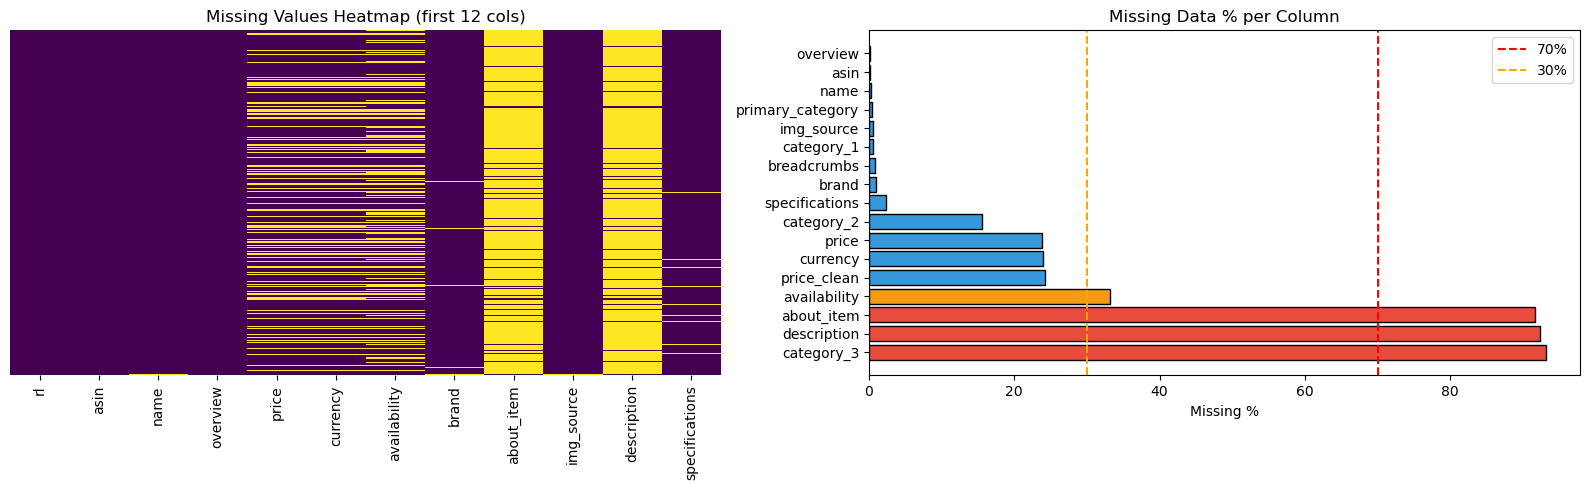

                  Missing Count  Missing Pct
category_3                 1350         93.2
description                1337         92.3
about_item                 1326         91.6
availability                481         33.2
price_clean                 350         24.2
currency                    346         23.9
price                       345         23.8
category_2                  226         15.6
specifications               35          2.4
brand                        14          1.0
breadcrumbs                  11          0.8
category_1                    9          0.6
img_source                    9          0.6
primary_category              6          0.4
name                          5          0.3
asin                          3          0.2
overview                      3          0.2


In [104]:
# Missing value summary
missing = pd.DataFrame({
    'Missing Count': df.isnull().sum(),
    'Missing Pct' : (df.isnull().sum() / len(df) * 100).round(1)
}).sort_values('Missing Pct', ascending=False)

fig, axes = plt.subplots(1, 2, figsize=(16, 5))

sns.heatmap(df[df.columns[:12]].isnull(), cbar=False, yticklabels=False,
            cmap='viridis', ax=axes[0])
axes[0].set_title('Missing Values Heatmap (first 12 cols)')

mv = missing[missing['Missing Pct'] > 0]
colors_mv = ['#e74c3c' if v > 70 else '#f39c12' if v > 30 else '#3498db'
             for v in mv['Missing Pct']]
axes[1].barh(mv.index, mv['Missing Pct'], color=colors_mv, edgecolor='black')
axes[1].axvline(70, color='red', linestyle='--', label='70%')
axes[1].axvline(30, color='orange', linestyle='--', label='30%')
axes[1].set_xlabel('Missing %'); axes[1].set_title('Missing Data % per Column')
axes[1].legend()

plt.tight_layout(); plt.show()
print(missing[missing['Missing Count'] > 0].to_string())

## 4.Ingeniería de Caraterísticas (Feature Engineering). <a id="s4"></a>

<div style="background:C48FFA; padding:12px; border-left:4px solid #C48FFA; border-radius:5px; color: #6909C8">
<b>Ejemplo Cotidiano:</b> Un agente inmobiliario no solo utilizar los metros cuadrados brutos, sino que tambien considera la ubicación, la antogüedad y
el estado. Nosotros hacemos lo mismo: extraemos informacion mas valiosa del texto sin procesar y las categorías..
</div> 

In [105]:
# ============================================================
# SECTION 3 — Feature Engineering
# ============================================================

# ── Category flags ───────────────────────────────────────────
df['is_book']    = (df['primary_category'] == 'Books').astype(int)
df['is_kindle']  = (df['primary_category'] == 'Kindle Store').astype(int)
df['is_sports']  = (df['primary_category'].str.contains('Sport', na=False)).astype(int)

# ── Sub-category flags ───────────────────────────────────────
df['is_fiction']    = df['category_1'].fillna('').str.contains('Fiction|Adventure|Crime|Romance|Sci-Fi', case=False).astype(int)
df['is_nonfiction'] = df['category_1'].fillna('').str.contains('History|Politics|Business|Science|Education', case=False).astype(int)
df['is_tech']       = df['category_1'].fillna('').str.contains('Computer|Programming|Technology', case=False).astype(int)
df['is_cycling']    = df['category_1'].fillna('').str.contains('Cycling', case=False).astype(int)

# ── Availability flags ───────────────────────────────────────
df['is_instock']     = (df['avail_clean'] == 'In Stock').astype(int)
df['is_unavailable'] = (df['avail_clean'] == 'Unavailable').astype(int)
df['is_lowstock']    = (df['avail_clean'] == 'Low Stock').astype(int)

# ── Price features ───────────────────────────────────────────
df['log_price'] = np.log1p(df['price_clean'])

def price_tier(p):
    if pd.isna(p):  return 'Unknown'
    if p < 300:     return '1_budget'
    if p < 800:     return '2_low'
    if p < 1500:    return '3_mid'
    if p < 3000:    return '4_premium'
    return '5_luxury'

df['price_tier'] = df['price_clean'].apply(price_tier)

# ── Label encode primary category ───────────────────────────
le_cat = LabelEncoder()
df['primary_cat_enc'] = le_cat.fit_transform(df['primary_category'].fillna('Unknown'))

le_cat1 = LabelEncoder()
df['cat1_enc'] = le_cat1.fit_transform(df['category_1'].fillna('Unknown'))

le_avail = LabelEncoder()
df['avail_enc'] = le_avail.fit_transform(df['avail_clean'])

print(f'✅ Total features engineered: {len(df.columns)}')
print('\nPrice tier distribution:')
print(df['price_tier'].value_counts().sort_index().to_string())
df[['name','price_clean','price_tier','primary_category','is_book','is_instock']].head(6)

✅ Total features engineered: 39

Price tier distribution:
price_tier
1_budget     104
2_low        287
3_mid        321
4_premium    260
5_luxury     126
Unknown      350


,name,price_clean,price_tier,primary_category,is_book,is_instock
0,Hands-On Design Patterns with C++: Solve commo...,1600.0,4_premium,Books,1,0
1,The Blazing Horizon The True Story of Pawnee B...,2399.0,4_premium,Books,1,0
2,Fast and easy lunch box: A collection of 15eas...,NaN,Unknown,Kindle Store,0,0
3,European Foreign Policy Scorecard 2014,NaN,Unknown,Kindle Store,0,0
4,The 13th Hour: Chaos (Volume 2) (The Nick Quin...,1849.0,4_premium,Books,1,0
5,Valerius Maximus' Memorable Deeds and Sayings ...,NaN,Unknown,Books,1,0


## 5.Análisis Univariado.<a id="s5"></a>

<div style="background:#E1BBFC; padding:12px; border-left:4px solid #BA63F8; border-radius:5px; color:#5E079C;">
<b>Pregunta clave:</b> 
 ¿Cómo es la distribución de precios?
 ¿Hay valores atípicos? ¿Los datos están sesgados?.in

</div>

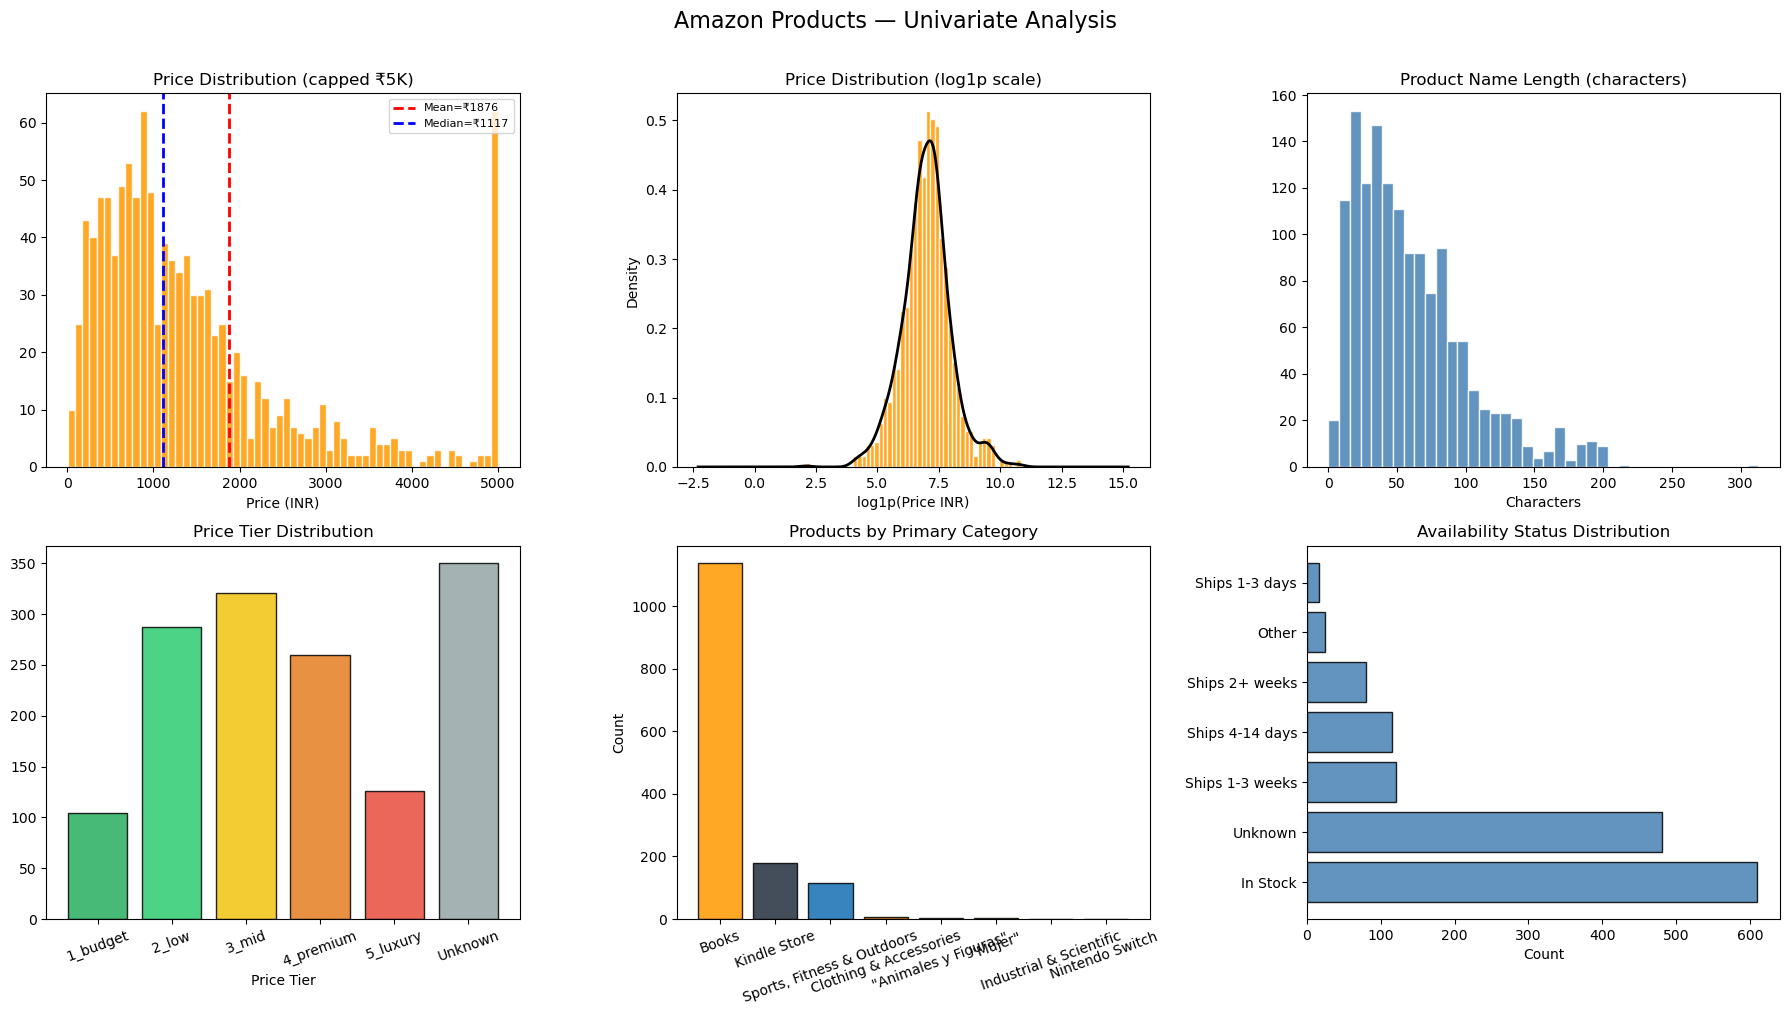

Shapiro-Wilk (log price, n=500): stat=0.9799, p=0.000002
Price is still non-normal after log transform

Price stats (INR):
count     1091.00
mean      1876.34
std       3334.04
min          7.00
25%        615.53
50%       1117.00
75%       1842.76
max      50555.00


In [106]:
# ============================================================
# SECTION 4 — Univariate Analysis
# ============================================================
df_priced = df[df['price_clean'].notna() & (df['price_clean'] > 0)].copy()

fig, axes = plt.subplots(2, 3, figsize=(18, 10))

# Price raw
axes[0,0].hist(df_priced['price_clean'].clip(upper=5000), bins=60,
               color='#FF9900', edgecolor='white', alpha=0.85)
axes[0,0].axvline(df_priced['price_clean'].mean(), color='red', linestyle='--',
                  lw=2, label=f'Mean=₹{df_priced["price_clean"].mean():.0f}')
axes[0,0].axvline(df_priced['price_clean'].median(), color='blue', linestyle='--',
                  lw=2, label=f'Median=₹{df_priced["price_clean"].median():.0f}')
axes[0,0].set_title('Price Distribution (capped ₹5K)')
axes[0,0].set_xlabel('Price (INR)'); axes[0,0].legend(fontsize=8)

# Price log
axes[0,1].hist(df_priced['log_price'], bins=50, color='#FF9900',
               edgecolor='white', alpha=0.85, density=True)
df_priced['log_price'].plot.kde(ax=axes[0,1], color='black', lw=2)
axes[0,1].set_title('Price Distribution (log1p scale)')
axes[0,1].set_xlabel('log1p(Price INR)')

# Name length
axes[0,2].hist(df['name_length'], bins=40, color='steelblue',
               edgecolor='white', alpha=0.85)
axes[0,2].set_title('Product Name Length (characters)')
axes[0,2].set_xlabel('Characters')

# Price tier
tier_counts = df['price_tier'].value_counts().sort_index()
tier_colors = ['#27ae60','#2ecc71','#f1c40f','#e67e22','#e74c3c','#95a5a6']
axes[1,0].bar(tier_counts.index, tier_counts.values,
              color=tier_colors[:len(tier_counts)], edgecolor='black', alpha=0.85)
axes[1,0].set_title('Price Tier Distribution')
axes[1,0].set_xlabel('Price Tier'); axes[1,0].tick_params(axis='x', rotation=20)

# Primary category
cat_counts = df['primary_category'].value_counts()
axes[1,1].bar(cat_counts.index, cat_counts.values,
              color=['#FF9900','#232F3E','#146EB4','#E47911','#999'],
              edgecolor='black', alpha=0.85)
axes[1,1].set_title('Products by Primary Category')
axes[1,1].set_ylabel('Count'); axes[1,1].tick_params(axis='x', rotation=20)

# Availability
avail_counts = df['avail_clean'].value_counts()
axes[1,2].barh(avail_counts.index, avail_counts.values,
               color='steelblue', edgecolor='black', alpha=0.85)
axes[1,2].set_title('Availability Status Distribution')
axes[1,2].set_xlabel('Count')

plt.suptitle('Amazon Products — Univariate Analysis', fontsize=16, y=1.01)
plt.tight_layout(); plt.show()

# Normality test
stat, p = shapiro(df_priced['log_price'].sample(min(500, len(df_priced)), random_state=42))
print(f'Shapiro-Wilk (log price, n=500): stat={stat:.4f}, p={p:.6f}')
print(f'Price is {"normally distributed after log transform" if p > 0.05 else "still non-normal after log transform"}')
print(f'\nPrice stats (INR):')
print(df_priced['price_clean'].describe().round(2).to_string())

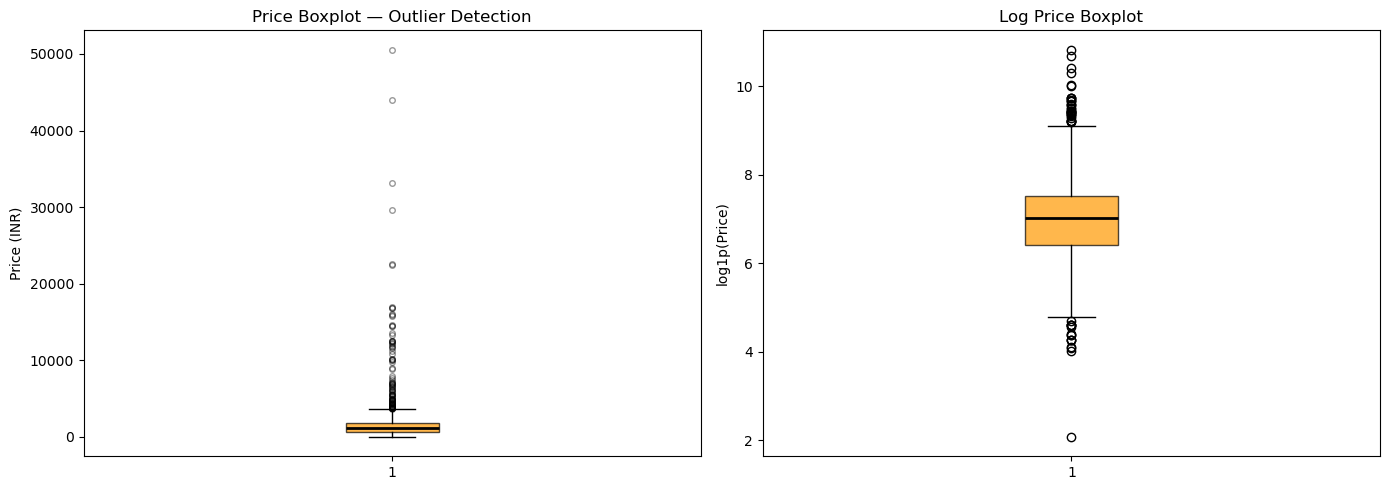

IQR method outliers: 93 (8.5%)
Price range (non-outlier): ₹-1225 – ₹3684

Top 10 most expensive products:
                                                                                                                                        name  price_clean           primary_category
                                            Sprache und Literatur (Literatur der julisch-claudischen und der flavischen Zeit [Schluss]): 032     50555.00                      Books
                                                         Data Mining Algorithms in C++: Data Patterns and Algorithms for Modern Applications     43936.00                      Books
                                                                                Birnbaum's Walt Disney World for Kids 2008 (Birnbaum Guides)     33180.00                      Books
                                                                            Professional Short Films with Autodesk 3ds Max (Graphics Series)     29633.00                 

In [107]:
# Outlier analysis — boxplot and IQR
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].boxplot(df_priced['price_clean'], patch_artist=True,
                boxprops=dict(facecolor='#FF9900', alpha=0.7),
                medianprops=dict(color='black', lw=2),
                flierprops=dict(marker='o', markersize=4, alpha=0.4, color='red'))
axes[0].set_title('Price Boxplot — Outlier Detection')
axes[0].set_ylabel('Price (INR)')

axes[1].boxplot(df_priced['log_price'], patch_artist=True,
                boxprops=dict(facecolor='#FF9900', alpha=0.7),
                medianprops=dict(color='black', lw=2))
axes[1].set_title('Log Price Boxplot')
axes[1].set_ylabel('log1p(Price)')

plt.tight_layout(); plt.show()

Q1, Q3 = df_priced['price_clean'].quantile([0.25, 0.75])
IQR = Q3 - Q1
outliers = df_priced[(df_priced['price_clean'] < Q1 - 1.5*IQR) |
                      (df_priced['price_clean'] > Q3 + 1.5*IQR)]
print(f'IQR method outliers: {len(outliers)} ({len(outliers)/len(df_priced)*100:.1f}%)')
print(f'Price range (non-outlier): ₹{Q1-1.5*IQR:.0f} – ₹{Q3+1.5*IQR:.0f}')
print(f'\nTop 10 most expensive products:')
print(df_priced.nlargest(10, 'price_clean')[['name','price_clean','primary_category']].to_string(index=False))

## 6.Análisis de categorías.<a id="s6"></a>

<div style="background:#E1BBFC; padding:12px; border-left:4px solid #BA63F8; border-radius:5px; color:#5E079C;">
<b>Pregunta clave:</b> 
¿Qué categorías tienen los precios más altos?
¿Qué subcategorías predominan? 
¿Dónde se encuentra la mejor relación calidad-precio?

</div>

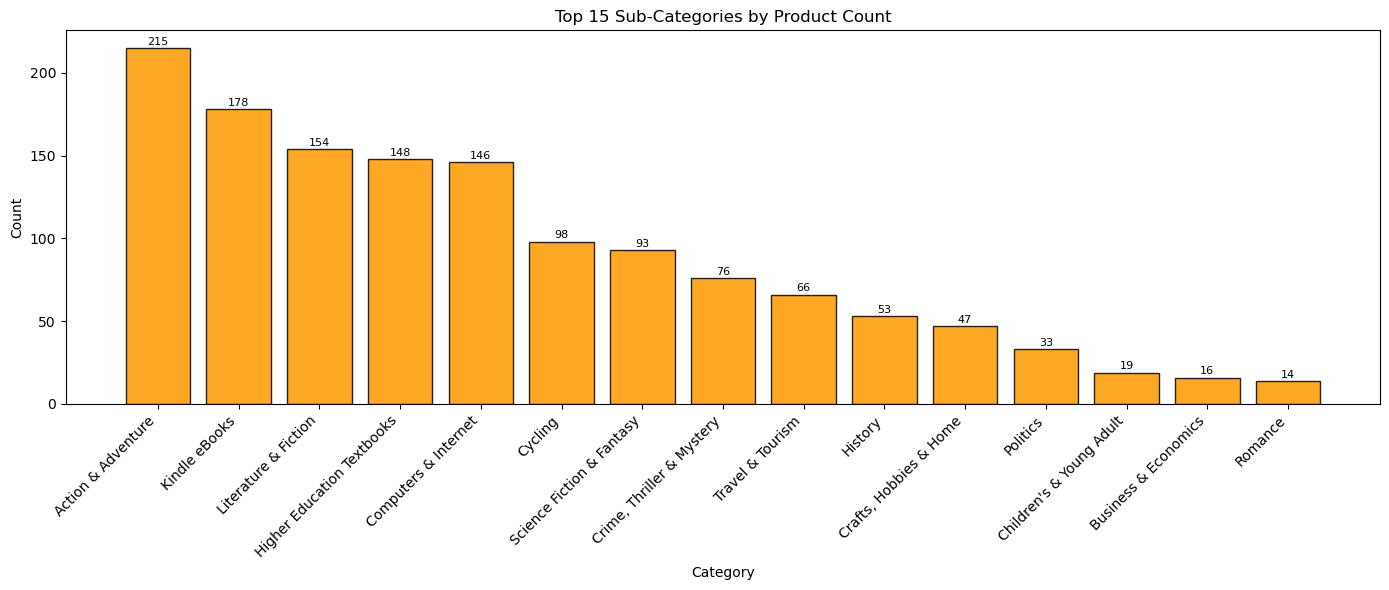

In [108]:
# ============================================================
# SECTION 5 — Category Analysis
# ============================================================
# Top 15 sub-categories by count
top15_cat1 = df['category_1'].value_counts().head(15)

plt.figure(figsize=(14, 6))
bars = plt.bar(top15_cat1.index, top15_cat1.values,
               color='#FF9900', edgecolor='black', alpha=0.85)
for bar, val in zip(bars, top15_cat1.values):
    plt.text(bar.get_x()+bar.get_width()/2, bar.get_height()+2,
             str(val), ha='center', fontsize=8)
plt.title('Top 15 Sub-Categories by Product Count')
plt.xlabel('Category'); plt.ylabel('Count')
plt.xticks(rotation=45, ha='right')
plt.tight_layout(); plt.show()


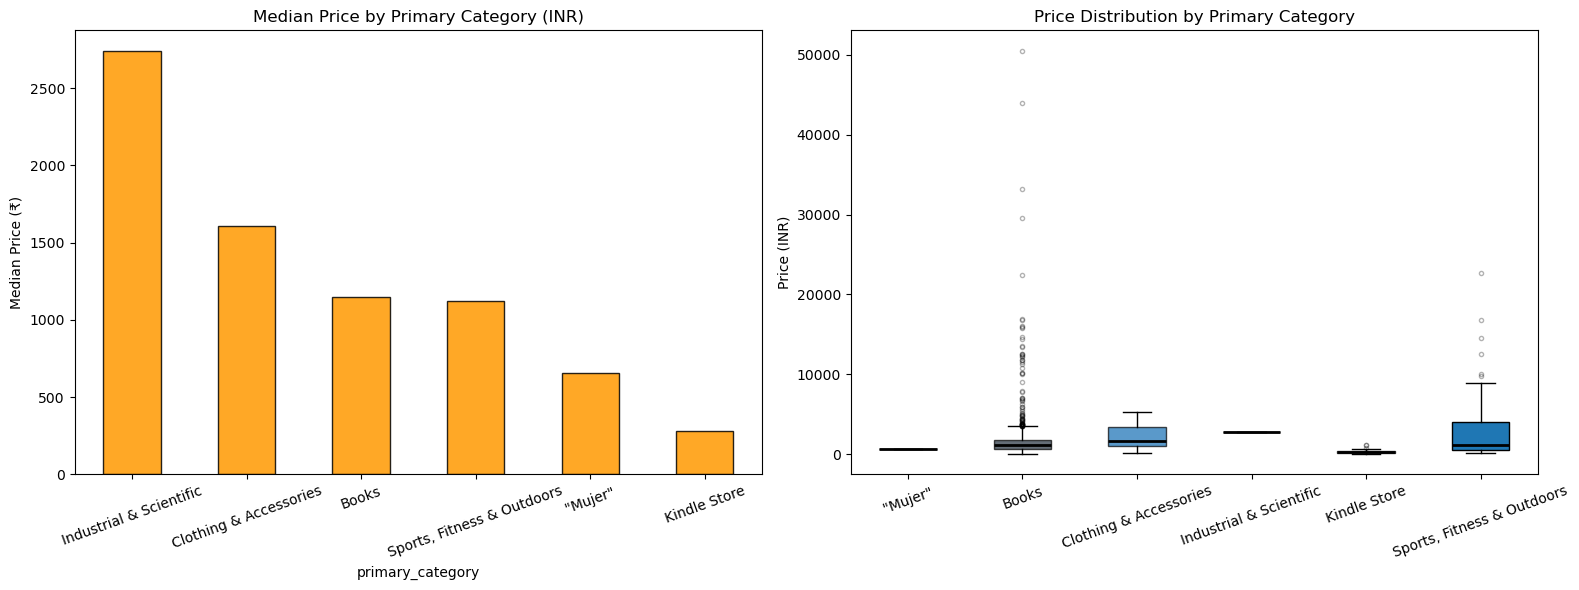

Price stats by primary category:
                              mean  median  count
primary_category                                 
 "Mujer"                     657.0   657.0      2
Books                       1825.3  1145.0    956
Clothing & Accessories      2249.2  1606.5      6
Industrial & Scientific     2738.0  2738.0      1
Kindle Store                 350.0   281.4     30
Sports, Fitness & Outdoors  2907.9  1125.0     93


In [109]:
# Price by primary category
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

cat_price = df_priced.groupby('primary_category')['price_clean'].agg(['mean','median','count']).round(1)
cat_price['median'].sort_values(ascending=False).plot.bar(
    ax=axes[0], color='#FF9900', edgecolor='black', alpha=0.85)
axes[0].set_title('Median Price by Primary Category (INR)')
axes[0].set_ylabel('Median Price (₹)')
axes[0].tick_params(axis='x', rotation=20)

# Boxplot
cat_groups = [df_priced[df_priced['primary_category']==c]['price_clean'].dropna()
              for c in cat_price.index]

bp = axes[1].boxplot(
    cat_groups,
    tick_labels=cat_price.index,  # ← cambio aquí
    patch_artist=True,
    medianprops=dict(color='black', lw=2),
    flierprops=dict(marker='o', markersize=3, alpha=0.3)
)

colors_cat = ['#FF9900','#232F3E','#146EB4','#E47911','#999']

for patch, color in zip(bp['boxes'], colors_cat):
    patch.set_facecolor(color)
    patch.set_alpha(0.7)

axes[1].set_title('Price Distribution by Primary Category')
axes[1].set_ylabel('Price (INR)')
axes[1].tick_params(axis='x', rotation=20)

plt.tight_layout()
plt.show()

print('Price stats by primary category:')
print(cat_price.to_string())

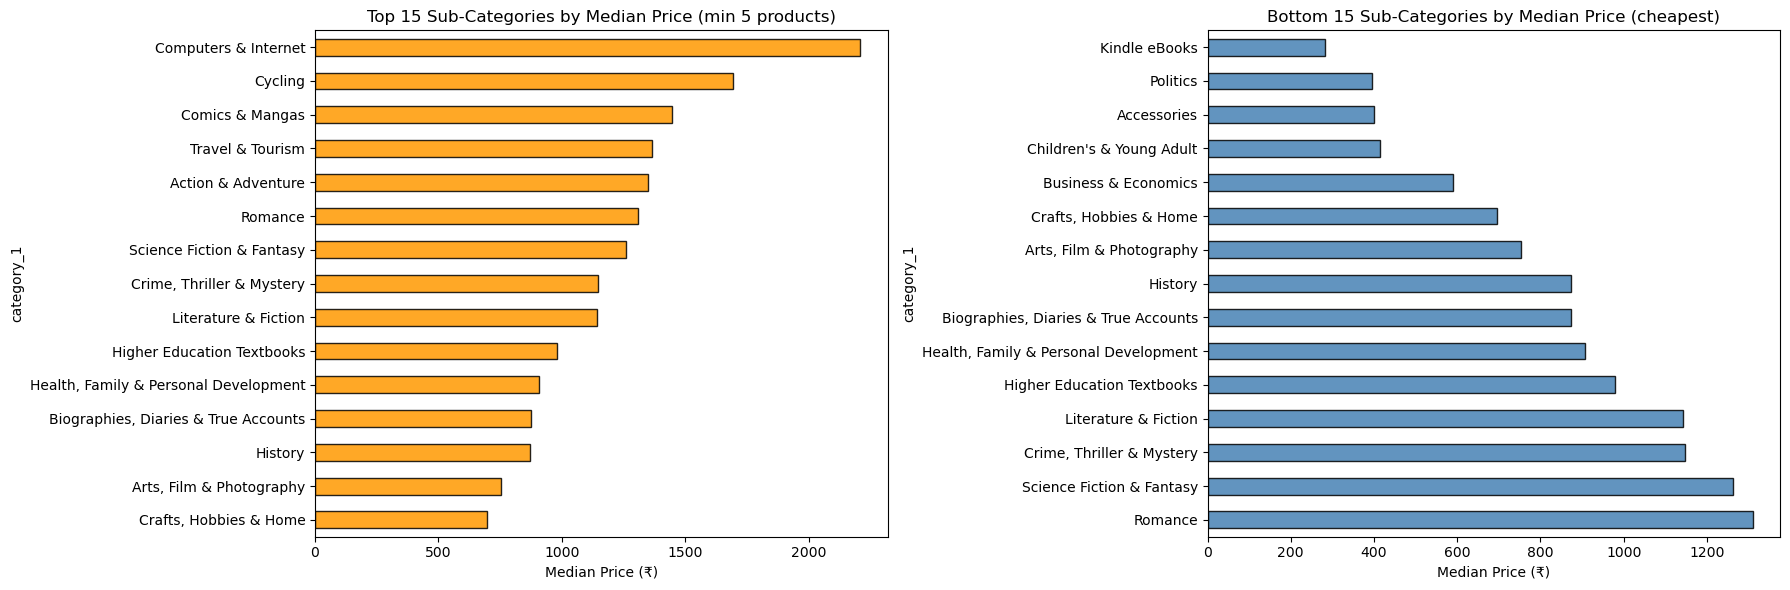

In [110]:
# Top 15 sub-categories by median price
top_cat1_price = (df_priced.groupby('category_1')['price_clean']
                  .agg(['median','count'])
                  .query('count >= 5')
                  .sort_values('median', ascending=False)
                  .head(15))

fig, axes = plt.subplots(1, 2, figsize=(18, 6))

top_cat1_price['median'].sort_values().plot.barh(
    ax=axes[0], color='#FF9900', edgecolor='black', alpha=0.85)
axes[0].set_title('Top 15 Sub-Categories by Median Price (min 5 products)')
axes[0].set_xlabel('Median Price (₹)')

# Bottom 15 (cheapest)
bottom_cat1 = (df_priced.groupby('category_1')['price_clean']
               .agg(['median','count'])
               .query('count >= 5')
               .sort_values('median')
               .head(15))
bottom_cat1['median'].sort_values(ascending=False).plot.barh(
    ax=axes[1], color='steelblue', edgecolor='black', alpha=0.85)
axes[1].set_title('Bottom 15 Sub-Categories by Median Price (cheapest)')
axes[1].set_xlabel('Median Price (₹)')

plt.tight_layout(); plt.show()

## 7.Análisis de disponibilidad.<a id="s7"></a>

<div style="background:#E1BBFC; padding:12px; border-left:4px solid #BA63F8; border-radius:5px; color:#5E079C;">
<b>Pregunta clave:</b> 
 ¿Influye la disponibilidad en el precio? 
 ¿Es más probable que los productos premium se agoten?

</div>

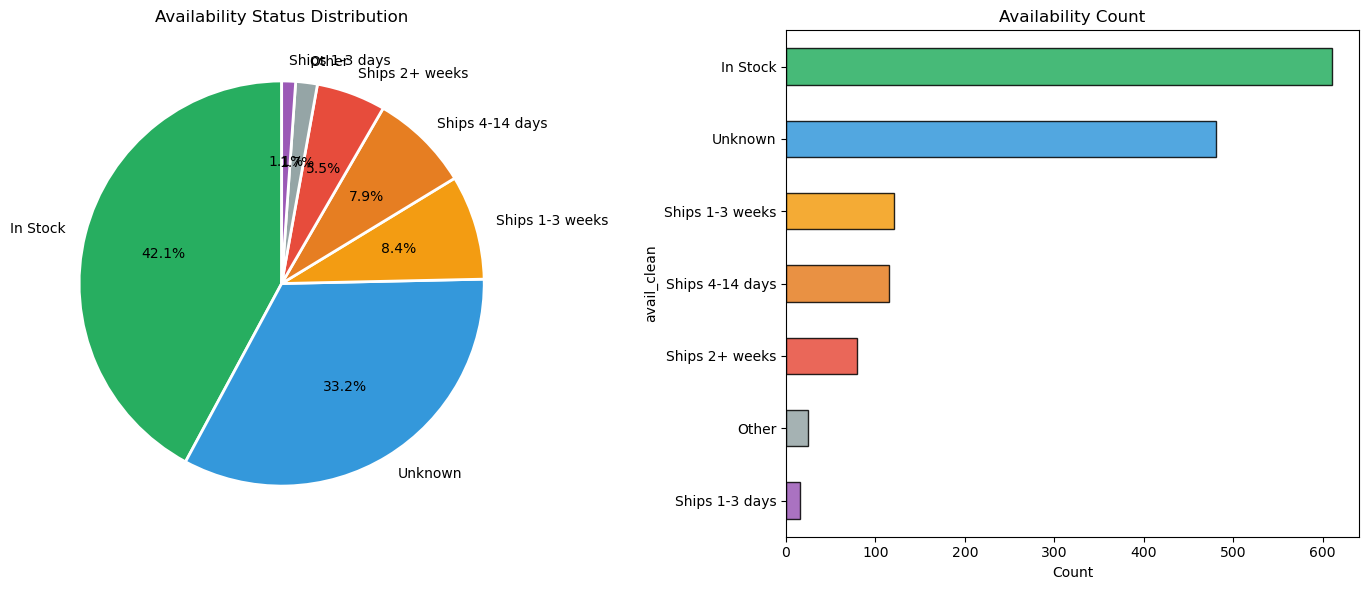

In [111]:
# ============================================================
# SECTION 6 — Availability Analysis
# ============================================================
avail_counts = df['avail_clean'].value_counts()
avail_colors = ['#27ae60','#3498db','#f39c12','#e67e22','#e74c3c','#95a5a6','#9b59b6','#1abc9c']

fig, axes = plt.subplots(1, 2, figsize=(14, 6))
axes[0].pie(avail_counts.values, labels=avail_counts.index,
            colors=avail_colors[:len(avail_counts)],
            autopct='%1.1f%%', startangle=90,
            wedgeprops=dict(edgecolor='white', linewidth=2))
axes[0].set_title('Availability Status Distribution')

avail_counts.sort_values().plot.barh(
    ax=axes[1], color=avail_colors[:len(avail_counts)][::-1],
    edgecolor='black', alpha=0.85)
axes[1].set_title('Availability Count')
axes[1].set_xlabel('Count')

plt.tight_layout(); plt.show()

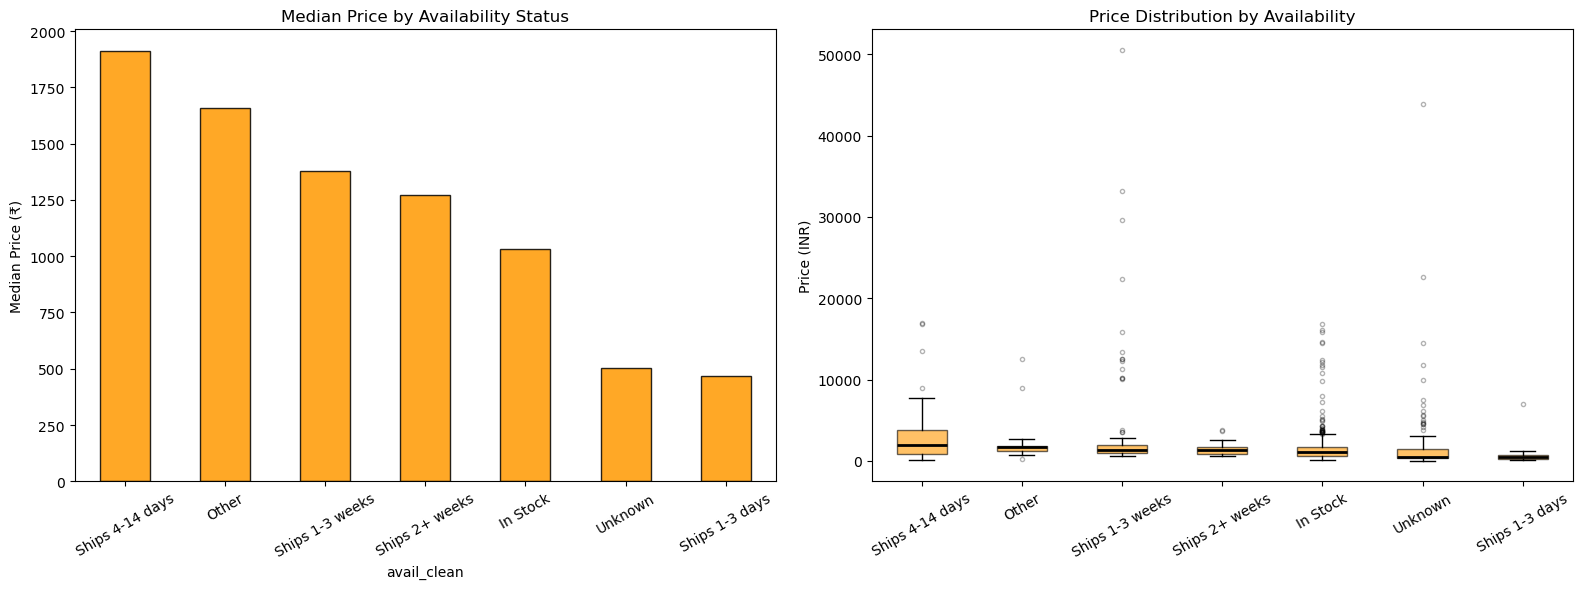

Price by availability:
                 median    mean  count
avail_clean                           
Ships 4-14 days  1912.3  2874.6    115
Other            1659.0  2295.5     22
Ships 1-3 weeks  1377.0  3231.6    121
Ships 2+ weeks   1273.0  1385.9     80
In Stock         1030.5  1489.0    602
Unknown           503.0  1879.4    135
Ships 1-3 days    469.0   874.9     16


In [112]:
# Price by availability status

avail_price = (
    df_priced.groupby('avail_clean')['price_clean']
    .agg(['median', 'mean', 'count'])
    .round(1)
)

avail_price = (
    avail_price[avail_price['count'] >= 5]
    .sort_values('median', ascending=False)
)

fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Bar chart
avail_price['median'].plot.bar(
    ax=axes[0],
    color='#FF9900',
    edgecolor='black',
    alpha=0.85
)

axes[0].set_title('Median Price by Availability Status')
axes[0].set_ylabel('Median Price (₹)')
axes[0].tick_params(axis='x', rotation=30)

# Boxplot
avail_groups = [
    df_priced[df_priced['avail_clean'] == a]['price_clean'].dropna()
    for a in avail_price.index
]

bp = axes[1].boxplot(
    avail_groups,
    tick_labels=avail_price.index,  # corregido
    patch_artist=True,
    medianprops=dict(color='black', lw=2),
    flierprops=dict(marker='o', markersize=3, alpha=0.3)
)

for patch in bp['boxes']:
    patch.set_facecolor('#FF9900')
    patch.set_alpha(0.6)

axes[1].set_title('Price Distribution by Availability')
axes[1].set_ylabel('Price (INR)')
axes[1].tick_params(axis='x', rotation=30)

plt.tight_layout()
plt.show()

print('Price by availability:')
print(avail_price.to_string())

## 8.Análisis de correlación y bivariado.<a id="s8"></a>

<div style="background:#E1BBFC; padding:12px; border-left:4px solid #BA63F8; border-radius:5px; color:#5E079C;">
<b>Pregunta clave:</b> 
 ¿Qué características están más correlacionadas con el precio?
    ¿La longitud del nombre predice el precio?

</div>

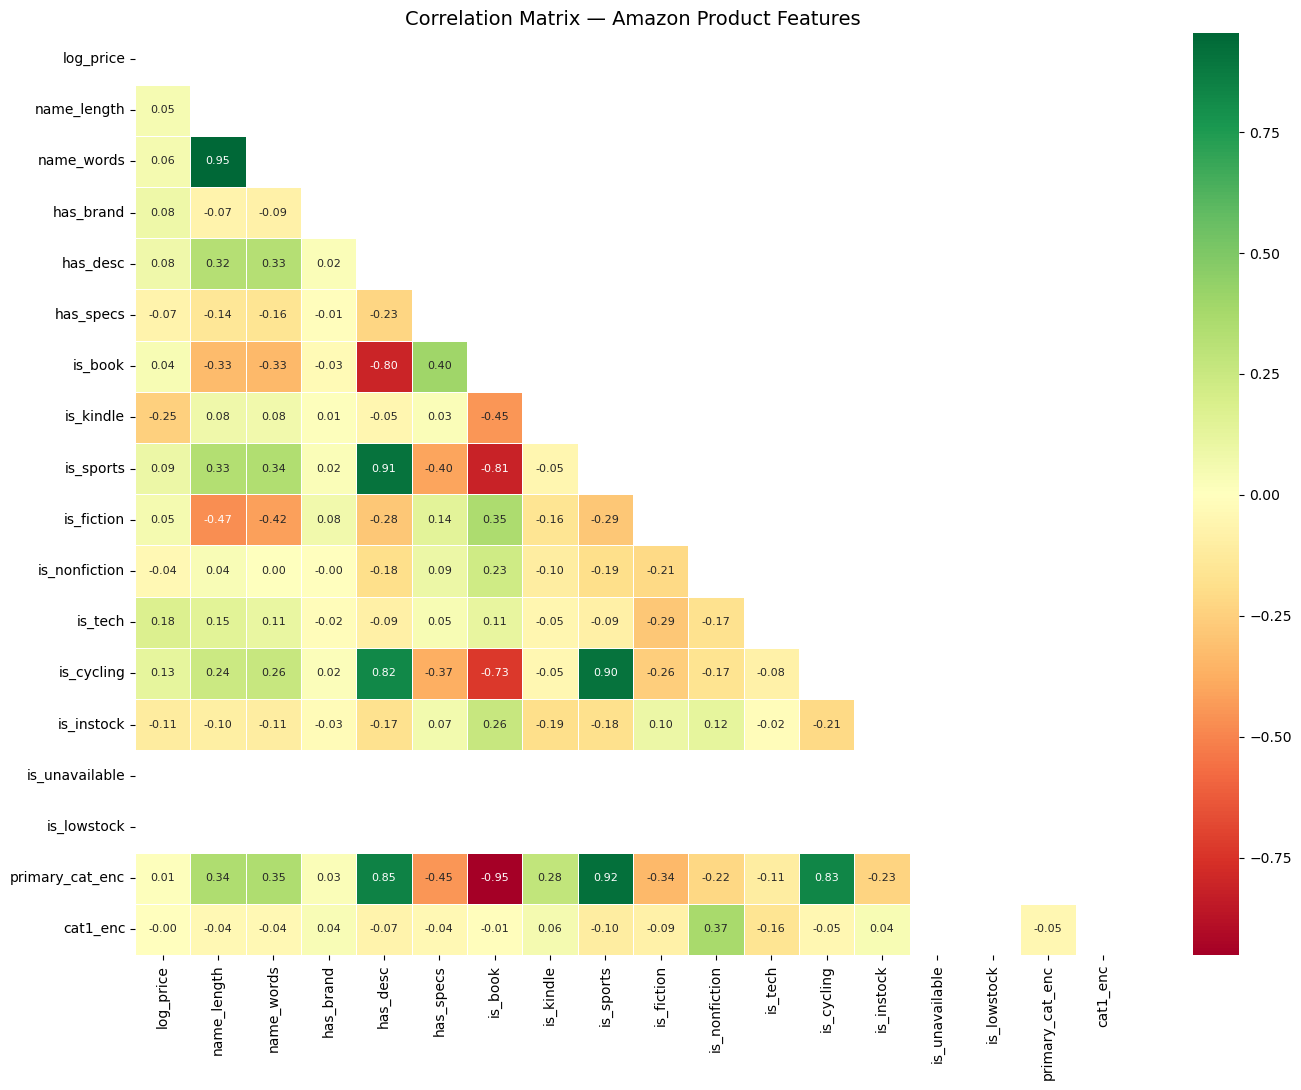

Top correlations with log_price:
is_tech            0.177104
is_cycling         0.127087
is_sports          0.092232
has_brand          0.083666
has_desc           0.081230
name_words         0.055766
is_fiction         0.054074
name_length        0.050457
is_book            0.038922
primary_cat_enc    0.009112
cat1_enc          -0.001280
is_nonfiction     -0.042769
has_specs         -0.071150
is_instock        -0.111712
is_kindle         -0.246386
is_unavailable          NaN
is_lowstock             NaN


In [113]:
# ============================================================
# SECTION 7 — Correlation Analysis
# ============================================================
corr_cols = ['log_price','name_length','name_words','has_brand','has_desc',
             'has_specs','is_book','is_kindle','is_sports','is_fiction',
             'is_nonfiction','is_tech','is_cycling','is_instock',
             'is_unavailable','is_lowstock','primary_cat_enc','cat1_enc']

corr = df_priced[corr_cols].corr()
mask = np.triu(np.ones_like(corr, dtype=bool))

plt.figure(figsize=(14, 11))
sns.heatmap(corr, mask=mask, annot=True, fmt='.2f', cmap='RdYlGn',
            center=0, linewidths=0.4, annot_kws={'size': 8})
plt.title('Correlation Matrix — Amazon Product Features', fontsize=14)
plt.tight_layout(); plt.show()

print('Top correlations with log_price:')
print(corr['log_price'].drop('log_price').sort_values(ascending=False).to_string())

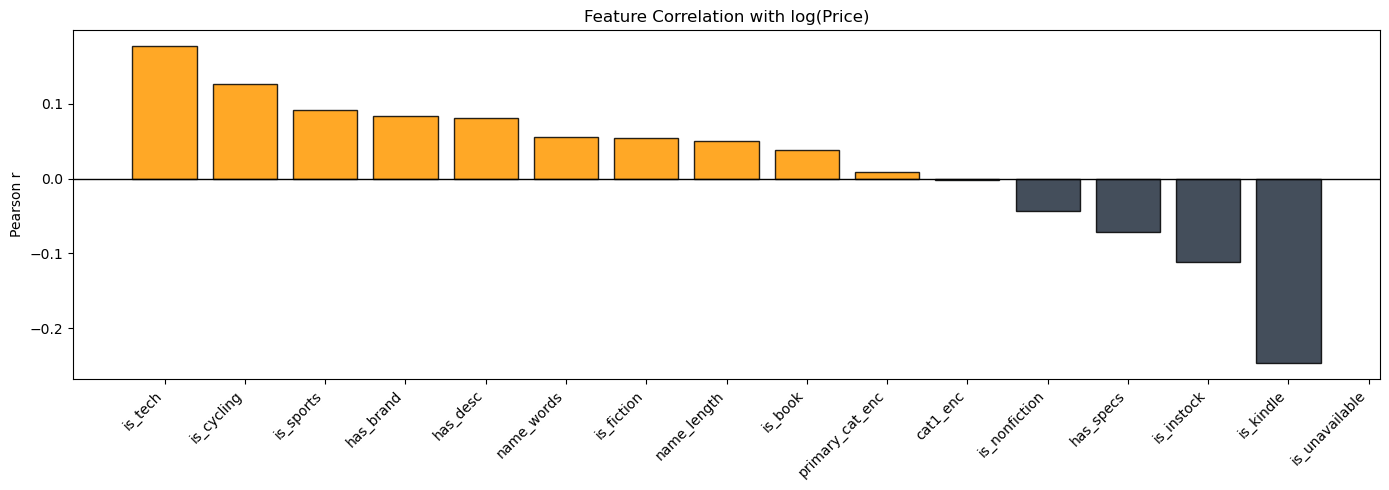

In [114]:
# Feature correlation bar chart
feat_corr = corr['log_price'].drop('log_price').sort_values(ascending=False)

plt.figure(figsize=(14, 5))
colors_fc = ['#FF9900' if v > 0 else '#232F3E' for v in feat_corr.values]
plt.bar(feat_corr.index, feat_corr.values, color=colors_fc, edgecolor='black', alpha=0.85)
plt.axhline(0, color='black', lw=1)
plt.title('Feature Correlation with log(Price)')
plt.ylabel('Pearson r'); plt.xticks(rotation=45, ha='right')
plt.tight_layout(); plt.show()

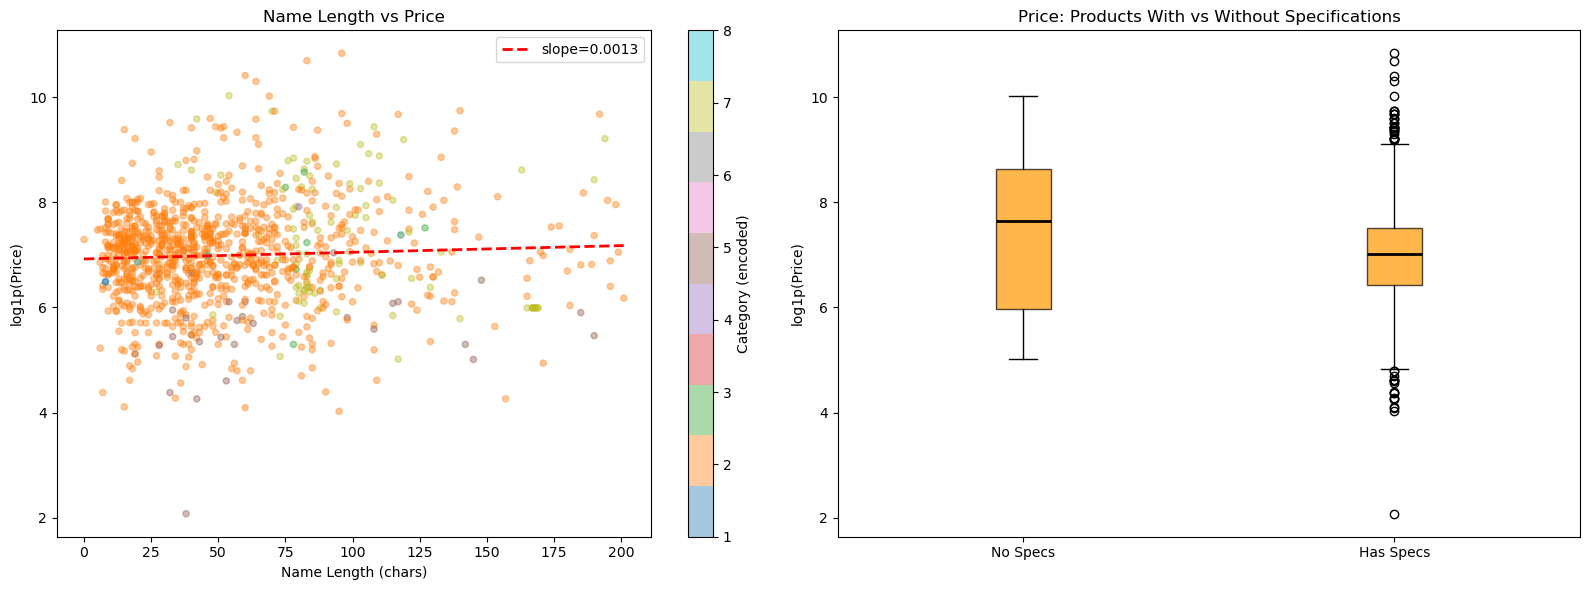

In [115]:
# Scatter: name length vs price
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

sc = axes[0].scatter(df_priced['name_length'], df_priced['log_price'],
                     c=df_priced['primary_cat_enc'], cmap='tab10',
                     alpha=0.4, s=20)
plt.colorbar(sc, ax=axes[0], label='Category (encoded)')
m, b = np.polyfit(df_priced['name_length'], df_priced['log_price'], 1)
x = np.linspace(0, df_priced['name_length'].max(), 100)
axes[0].plot(x, m*x+b, 'r--', lw=2, label=f'slope={m:.4f}')
axes[0].set_xlabel('Name Length (chars)'); axes[0].set_ylabel('log1p(Price)')
axes[0].set_title('Name Length vs Price'); axes[0].legend()

# Price by has_specs
axes[1].boxplot(
    [np.log1p(df_priced[df_priced['has_specs']==0]['price_clean']),
     np.log1p(df_priced[df_priced['has_specs']==1]['price_clean'])],
    tick_labels=['No Specs', 'Has Specs'],
    patch_artist=True,
    boxprops=dict(facecolor='#FF9900', alpha=0.7),
    medianprops=dict(color='black', lw=2)
)
axes[1].set_title('Price: Products With vs Without Specifications')
axes[1].set_ylabel('log1p(Price)')

plt.tight_layout(); plt.show()

## 9.Prueba de hipótesis estadísticas.<a id="s9"></a>

<div style="background:#E1BBFC; padding:12px; border-left:4px solid #BA63F8; border-radius:5px; color:#5E079C;">
<b>Utilizamos pruebas no paramétricas (Kruskal-Wallis, U de Mann-Whitney) porque el precio presenta una distribución muy asimétrica y no es normal. α = 0,05.</b> 


</div>

| # | Hipótesis | Prueba |
| :--- | :--- | :--- |
| H1 | El precio difiere significativamente entre las categorías principales | Kruskal-Wallis |
| H2 | El precio de los libros es significativamente menor que el de los productos deportivos | U de Mann-Whitney |
| H3 | Los productos en stock tienen un precio diferente al de los no disponibles | U de Mann-Whitney |
| H4 | La longitud del nombre está correlacionada positivamente con el precio | Correlación de Spearman |
| H5 | Los productos con especificaciones tienen un precio más alto | U de Mann-Whitney |

In [116]:
# ============================================================
# SECTION 8 — Hypothesis Testing
# ============================================================

from scipy.stats import mannwhitneyu, kruskal, spearmanr

alpha = 0.05

def mw_test(name, a, b, la, lb):
    a = a.dropna()
    b = b.dropna()

    if len(a) == 0 or len(b) == 0:
        print(f'{name}')
        print('  ERROR: One of the groups has no valid data.')
        print()
        return None

    u, p = mannwhitneyu(a, b, alternative='two-sided')

    print(f'{name}')
    print(f'  {la}: n={len(a)}, median=₹{a.median():.0f}')
    print(f'  {lb}: n={len(b)}, median=₹{b.median():.0f}')
    print(f'  Mann-Whitney U={u:.0f}, p={p:.6f}')
    print(f'  RESULT: {"✅ REJECT H0 — Significant difference." if p < alpha else "❌ FAIL TO REJECT H0."}')
    print()

    return p


# H1: Price across primary categories — Kruskal-Wallis
cat_groups_kw = []
cat_labels_kw = []

for c in df_priced['primary_category'].dropna().unique():
    g = df_priced[df_priced['primary_category'] == c]['price_clean'].dropna()

    if len(g) >= 5:
        cat_groups_kw.append(g)
        cat_labels_kw.append(c)

if len(cat_groups_kw) >= 2:
    h1, p1 = kruskal(*cat_groups_kw)

    print('H1: Price across Primary Categories — Kruskal-Wallis')
    for label, g in zip(cat_labels_kw, cat_groups_kw):
        print(f'  {str(label):35s}: n={len(g)}, median=₹{g.median():.0f}')

    print(f'  H={h1:.4f}, p={p1:.6f}')
    print(f'  RESULT: {"✅ REJECT H0 — Price differs across categories." if p1 < alpha else "❌ FAIL TO REJECT H0."}')
    print()
else:
    h1, p1 = None, None
    print('H1: Price across Primary Categories — Kruskal-Wallis')
    print('  ERROR: Not enough valid category groups for Kruskal-Wallis test.')
    print()


# H2: Books vs Sports
p2 = mw_test(
    'H2: Books vs Sports Products Price',
    df_priced[df_priced['is_book'] == 1]['price_clean'],
    df_priced[df_priced['is_sports'] == 1]['price_clean'],
    'Books',
    'Sports'
)


# H3: In Stock vs Unavailable
p3 = mw_test(
    'H3: In-Stock vs Unavailable Price',
    df_priced[df_priced['is_instock'] == 1]['price_clean'],
    df_priced[df_priced['is_unavailable'] == 1]['price_clean'],
    'In Stock',
    'Unavailable'
)


# H4: Name length vs price — Spearman
spearman_data = df_priced[['name_length', 'price_clean']].dropna()

if len(spearman_data) >= 2:
    rho4, p4 = spearmanr(
        spearman_data['name_length'],
        spearman_data['price_clean']
    )

    print('H4: Name Length vs Price — Spearman Correlation')
    print(f'  rho={rho4:.4f}, p={p4:.6f}')
    print(f'  RESULT: {"✅ REJECT H0 — Significant correlation." if p4 < alpha else "❌ FAIL TO REJECT H0."}')
    print()
else:
    rho4, p4 = None, None
    print('H4: Name Length vs Price — Spearman Correlation')
    print('  ERROR: Not enough valid data for Spearman correlation.')
    print()


# H5: Has specs vs no specs
p5 = mw_test(
    'H5: Products With vs Without Specifications',
    df_priced[df_priced['has_specs'] == 1]['price_clean'],
    df_priced[df_priced['has_specs'] == 0]['price_clean'],
    'Has Specs',
    'No Specs'
)

H1: Price across Primary Categories — Kruskal-Wallis
  Books                              : n=956, median=₹1145
  Sports, Fitness & Outdoors         : n=93, median=₹1125
  Kindle Store                       : n=30, median=₹281
  Clothing & Accessories             : n=6, median=₹1606
  H=55.8870, p=0.000000
  RESULT: ✅ REJECT H0 — Price differs across categories.

H2: Books vs Sports Products Price
  Books: n=956, median=₹1145
  Sports: n=93, median=₹1125
  Mann-Whitney U=40297, p=0.136163
  RESULT: ❌ FAIL TO REJECT H0.

H3: In-Stock vs Unavailable Price
  ERROR: One of the groups has no valid data.

H4: Name Length vs Price — Spearman Correlation
  rho=0.0362, p=0.232438
  RESULT: ❌ FAIL TO REJECT H0.

H5: Products With vs Without Specifications
  Has Specs: n=1067, median=₹1116
  No Specs: n=24, median=₹2169
  Mann-Whitney U=10452, p=0.123380
  RESULT: ❌ FAIL TO REJECT H0.



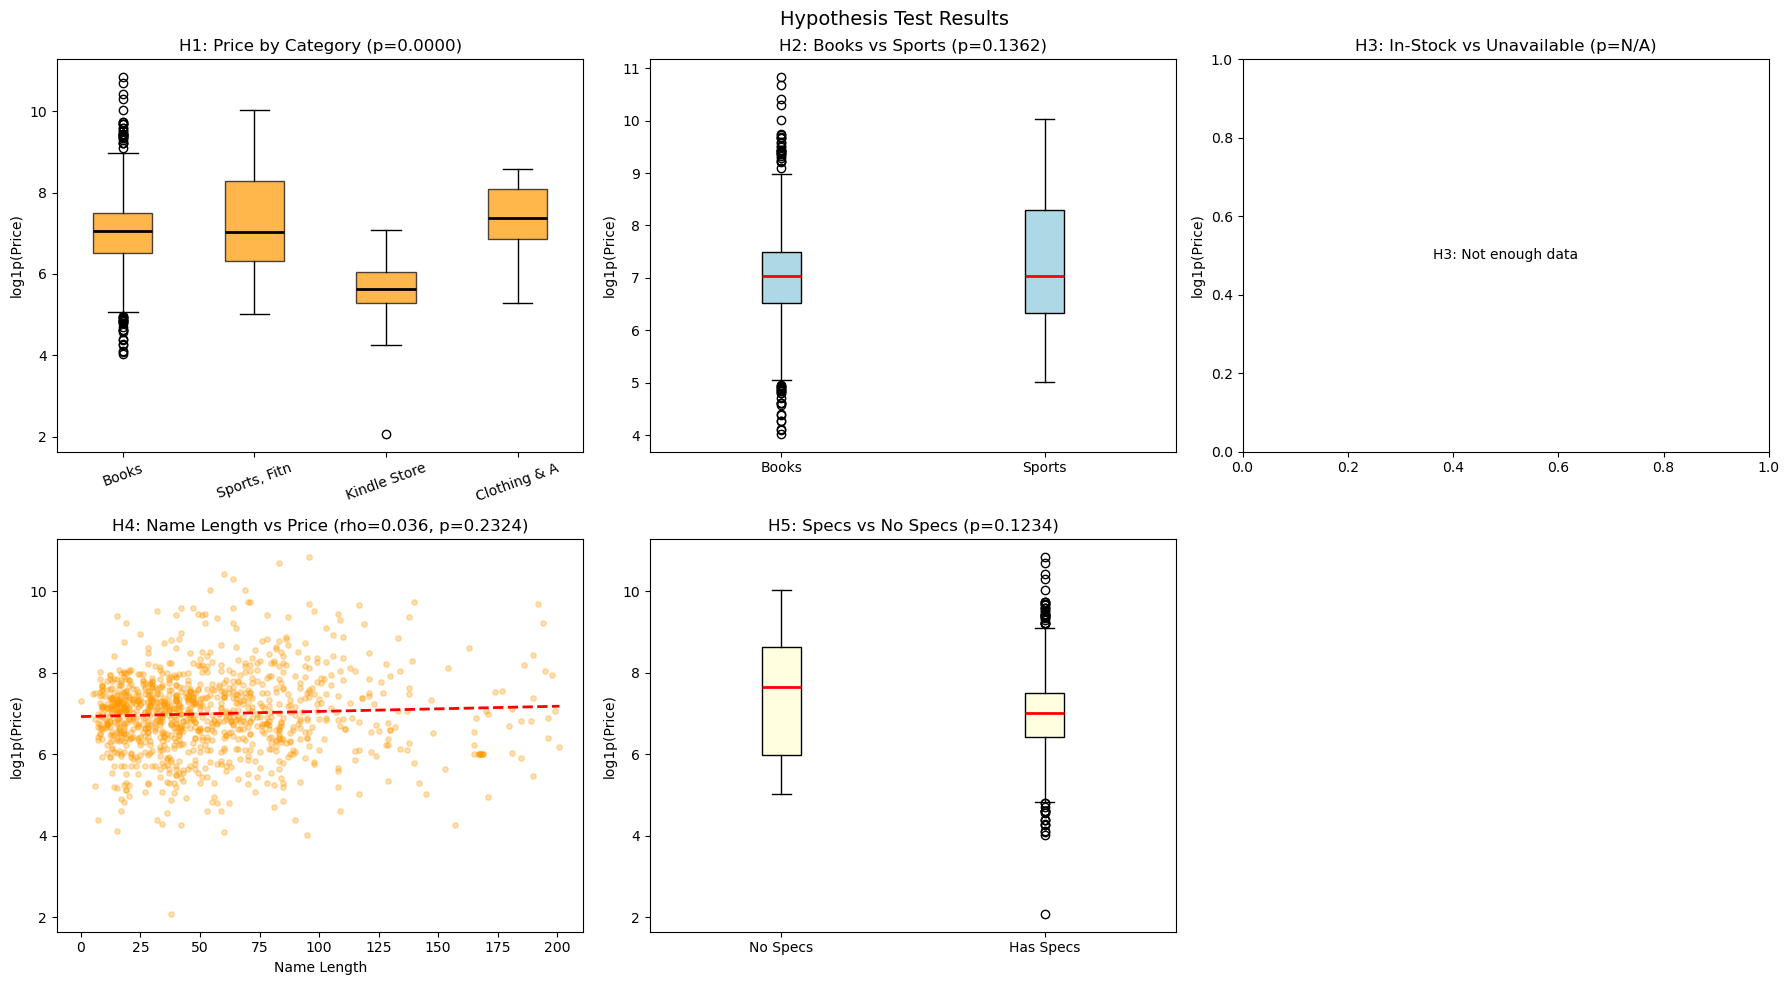

In [117]:
# ============================================================
# Visualise hypothesis results
# ============================================================

def fmt_p(p):
    return "N/A" if p is None else f"{p:.4f}"

def valid_values(s):
    return s.dropna()

fig, axes = plt.subplots(2, 3, figsize=(18, 10))

# H1
if p1 is not None and len(cat_groups_kw) >= 2:
    axes[0,0].boxplot(
        [np.log1p(g) for g in cat_groups_kw],
        tick_labels=[str(l)[:12] for l in cat_labels_kw],
        patch_artist=True,
        boxprops=dict(facecolor='#FF9900', alpha=0.7),
        medianprops=dict(color='black', lw=2)
    )
    axes[0,0].set_title(f'H1: Price by Category (p={fmt_p(p1)})')
    axes[0,0].set_ylabel('log1p(Price)')
    axes[0,0].tick_params(axis='x', rotation=20)
else:
    axes[0,0].text(0.5, 0.5, 'H1: Not enough data', ha='center', va='center')
    axes[0,0].set_title('H1: Price by Category')


# H2
books = valid_values(df_priced[df_priced['is_book'] == 1]['price_clean'])
sports = valid_values(df_priced[df_priced['is_sports'] == 1]['price_clean'])

if len(books) > 0 and len(sports) > 0:
    axes[0,1].boxplot(
        [np.log1p(books), np.log1p(sports)],
        tick_labels=['Books', 'Sports'],
        patch_artist=True,
        boxprops=dict(facecolor='lightblue'),
        medianprops=dict(color='red', lw=2)
    )
else:
    axes[0,1].text(0.5, 0.5, 'H2: Not enough data', ha='center', va='center')

axes[0,1].set_title(f'H2: Books vs Sports (p={fmt_p(p2)})')
axes[0,1].set_ylabel('log1p(Price)')


# H3
instock = valid_values(df_priced[df_priced['is_instock'] == 1]['price_clean'])
unavailable = valid_values(df_priced[df_priced['is_unavailable'] == 1]['price_clean'])

if len(instock) > 0 and len(unavailable) > 0:
    axes[0,2].boxplot(
        [np.log1p(instock), np.log1p(unavailable)],
        tick_labels=['In Stock', 'Unavailable'],
        patch_artist=True,
        boxprops=dict(facecolor='lightgreen'),
        medianprops=dict(color='red', lw=2)
    )
else:
    axes[0,2].text(0.5, 0.5, 'H3: Not enough data', ha='center', va='center')

axes[0,2].set_title(f'H3: In-Stock vs Unavailable (p={fmt_p(p3)})')
axes[0,2].set_ylabel('log1p(Price)')


# H4
scatter_data = df_priced[['name_length', 'log_price']].dropna()

if len(scatter_data) >= 2:
    axes[1,0].scatter(
        scatter_data['name_length'],
        scatter_data['log_price'],
        alpha=0.3,
        color='#FF9900',
        s=15
    )

    m, b = np.polyfit(scatter_data['name_length'], scatter_data['log_price'], 1)
    x = np.linspace(0, scatter_data['name_length'].max(), 100)

    axes[1,0].plot(x, m * x + b, 'r--', lw=2)
    axes[1,0].set_title(f'H4: Name Length vs Price (rho={rho4:.3f}, p={fmt_p(p4)})')
else:
    axes[1,0].text(0.5, 0.5, 'H4: Not enough data', ha='center', va='center')
    axes[1,0].set_title('H4: Name Length vs Price')

axes[1,0].set_xlabel('Name Length')
axes[1,0].set_ylabel('log1p(Price)')


# H5
no_specs = valid_values(df_priced[df_priced['has_specs'] == 0]['price_clean'])
has_specs = valid_values(df_priced[df_priced['has_specs'] == 1]['price_clean'])

if len(no_specs) > 0 and len(has_specs) > 0:
    axes[1,1].boxplot(
        [np.log1p(no_specs), np.log1p(has_specs)],
        tick_labels=['No Specs', 'Has Specs'],
        patch_artist=True,
        boxprops=dict(facecolor='lightyellow'),
        medianprops=dict(color='red', lw=2)
    )
else:
    axes[1,1].text(0.5, 0.5, 'H5: Not enough data', ha='center', va='center')

axes[1,1].set_title(f'H5: Specs vs No Specs (p={fmt_p(p5)})')
axes[1,1].set_ylabel('log1p(Price)')


axes[1,2].set_visible(False)

plt.suptitle('Hypothesis Test Results', fontsize=14)
plt.tight_layout()
plt.show()

## 10.Formulación de problemas de aprendizaje automático.<a id="s10"></a>

<div style="background:#E1BBFC; padding:12px; border-left:4px solid #BA63F8; border-radius:5px; color:#5E079C;">
<b>Tarea: Predecir el precio del producto (en escala logarítmica) a partir de la categoría, la longitud del nombre, la disponibilidad y los indicadores de características.</b> 


¿Por qué usar la escala logarítmica? El precio original presenta una fuerte asimetría positiva. La transformación lo hace más normal y evita que los valores atípicos costosos dominen la función de pérdida.


</div>

✅ ML dataset shape : (1091, 20)
✅ Features         : 18

Train: 872 | Test: 219


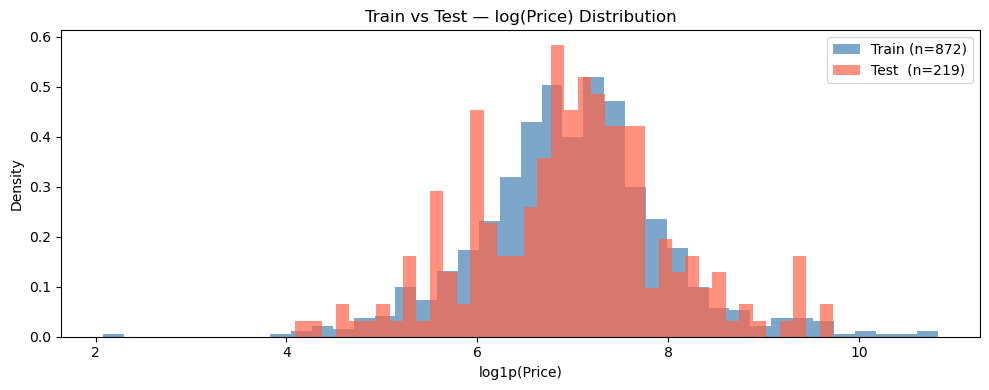

✅ Distributions look similar — good split!


In [118]:
# ============================================================
# SECTION 9 — ML Problem Framing
# ============================================================

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

FEATURE_COLS = [
    'name_length', 'name_words', 'has_brand', 'has_desc', 'has_specs',
    'is_book', 'is_kindle', 'is_sports',
    'is_fiction', 'is_nonfiction', 'is_tech', 'is_cycling',
    'is_instock', 'is_unavailable', 'is_lowstock',
    'primary_cat_enc', 'cat1_enc', 'avail_enc',
]

TARGET = 'log_price'

required_cols = FEATURE_COLS + [TARGET, 'price_clean']
missing_cols = [col for col in required_cols if col not in df_priced.columns]

if missing_cols:
    raise KeyError(f"Missing columns in df_priced: {missing_cols}")

df_ml = df_priced[required_cols].dropna().copy()

print(f'✅ ML dataset shape : {df_ml.shape}')
print(f'✅ Features         : {len(FEATURE_COLS)}')

if df_ml.empty:
    raise ValueError("df_ml is empty after dropna(). Check missing values in selected features or target.")

X = df_ml[FEATURE_COLS]
y = df_ml[TARGET]

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

scaler = StandardScaler()
X_train_s = scaler.fit_transform(X_train)
X_test_s = scaler.transform(X_test)

print(f'\nTrain: {len(X_train):,} | Test: {len(X_test):,}')

# Visualise split
fig, ax = plt.subplots(figsize=(10, 4))

ax.hist(
    y_train,
    bins=40,
    color='steelblue',
    alpha=0.7,
    label=f'Train (n={len(y_train)})',
    density=True
)

ax.hist(
    y_test,
    bins=40,
    color='tomato',
    alpha=0.7,
    label=f'Test  (n={len(y_test)})',
    density=True
)

ax.set_title('Train vs Test — log(Price) Distribution')
ax.set_xlabel('log1p(Price)')
ax.set_ylabel('Density')
ax.legend()

plt.tight_layout()
plt.show()

print('✅ Distributions look similar — good split!')

## 11.Marco de selección de modelos.<a id="s11"></a>

| Modelo | Fortalezas | Debilidades | Ideal para |
| :--- | :--- | :--- | :--- |
| **Regresión Lineal** | Rápido, interpretable | Asume linealidad | Línea base (*Baseline*) |
| **Regresión Ridge** | Maneja la multicolinealidad | Sigue siendo lineal | Características correlacionadas |
| **Regresión Lasso** | Selección de características integrada | Puede reducir a cero características útiles | Características dispersas (*Sparse*) |
| **Random Forest** | No lineal, robusto | Menos interpretable | Patrones complejos |
| **XGBoost / GBM** | Máxima precisión | Requiere ajuste de parámetros (*Tuning*) | Datos tabulares |

### Métricas de Evaluación

* **MAE** — Error Absoluto Medio en escala logarítmica (menor = mejor)
* **RMSE** — Raíz del Error Cuadrático Medio (penaliza los errores grandes)
* **$R^2$** — Varianza explicada (mayor = mejor, máx. 1.0)
* **MAE (₹)** — Transformado de vuelta a INR (rupias indias) para una interpretación de negocio

In [119]:
# ============================================================
# SECTION 10 — Evaluation Helpers
# ============================================================
results = {}

def eval_model(name, y_true, y_pred):
    mae  = mean_absolute_error(y_true, y_pred)
    rmse = np.sqrt(mean_squared_error(y_true, y_pred))
    r2   = r2_score(y_true, y_pred)
    mae_inr = mean_absolute_error(np.expm1(y_true), np.expm1(y_pred))
    print(f'  📊 {name}:')
    print(f'     MAE (log)  = {mae:.4f}  |  MAE (₹) = ₹{mae_inr:,.0f}')
    print(f'     RMSE (log) = {rmse:.4f}  |  R²      = {r2:.4f}')
    results[name] = {'MAE_log': round(mae,4), 'RMSE_log': round(rmse,4),
                     'R2': round(r2,4), 'MAE_INR': round(mae_inr,0)}
    return y_pred

print('✅ Evaluation helpers ready.')

✅ Evaluation helpers ready.


## 12.Modelos de regresión: predicción del precio de Amazon.<a id="s12"></a>

<div style="background:#E1BBFC; padding:12px; border-left:4px solid #BA63F8; border-radius:5px; color:#5E079C;">
<b>Entrenamos 5 modelos y los comparamos en el mismo conjunto de prueba.</b> 


</div>

In [120]:
# ============================================================
# SECTION 11 — Train All Models
# ============================================================

print('='*60)
print('TRAINING ALL MODELS')
print('='*60)

# ------------------------------------------------------------
# Check XGBoost availability
# ------------------------------------------------------------
try:
    import xgboost as xgb
    XGB_AVAILABLE = True
except ImportError:
    XGB_AVAILABLE = False


# 1. Linear Regression
lr = LinearRegression()
lr.fit(X_train_s, y_train)

lr_pred = eval_model(
    'Linear Regression',
    y_test,
    lr.predict(X_test_s)
)


# 2. Ridge Regression
ridge = Ridge(alpha=10.0)
ridge.fit(X_train_s, y_train)

ridge_pred = eval_model(
    'Ridge Regression',
    y_test,
    ridge.predict(X_test_s)
)


# 3. Lasso Regression
lasso = Lasso(alpha=0.01, max_iter=5000)
lasso.fit(X_train_s, y_train)

lasso_pred = eval_model(
    'Lasso Regression',
    y_test,
    lasso.predict(X_test_s)
)


# 4. Random Forest
rf = RandomForestRegressor(
    n_estimators=300,
    max_depth=10,
    min_samples_leaf=3,
    random_state=42,
    n_jobs=-1
)

rf.fit(X_train, y_train)

rf_pred = eval_model(
    'Random Forest',
    y_test,
    rf.predict(X_test)
)


# 5. XGBoost / Gradient Boosting
if XGB_AVAILABLE:

    xgb_model = xgb.XGBRegressor(
        n_estimators=400,
        learning_rate=0.05,
        max_depth=5,
        subsample=0.8,
        colsample_bytree=0.8,
        random_state=42,
        verbosity=0
    )

    xgb_model.fit(
        X_train,
        y_train
    )

    xgb_pred = eval_model(
        'XGBoost',
        y_test,
        xgb_model.predict(X_test)
    )


else:

    gbm = GradientBoostingRegressor(
        n_estimators=300,
        learning_rate=0.05,
        max_depth=5,
        subsample=0.8,
        random_state=42
    )

    gbm.fit(
        X_train,
        y_train
    )

    xgb_pred = eval_model(
        'Gradient Boosting',
        y_test,
        gbm.predict(X_test)
    )

TRAINING ALL MODELS
  📊 Linear Regression:
     MAE (log)  = 0.6974  |  MAE (₹) = ₹1,170
     RMSE (log) = 0.9430  |  R²      = 0.1529
  📊 Ridge Regression:
     MAE (log)  = 0.6967  |  MAE (₹) = ₹1,168
     RMSE (log) = 0.9425  |  R²      = 0.1538
  📊 Lasso Regression:
     MAE (log)  = 0.6988  |  MAE (₹) = ₹1,170
     RMSE (log) = 0.9445  |  R²      = 0.1502
  📊 Random Forest:
     MAE (log)  = 0.6533  |  MAE (₹) = ₹1,141
     RMSE (log) = 0.8872  |  R²      = 0.2500
  📊 Gradient Boosting:
     MAE (log)  = 0.6797  |  MAE (₹) = ₹1,175
     RMSE (log) = 0.9094  |  R²      = 0.2120


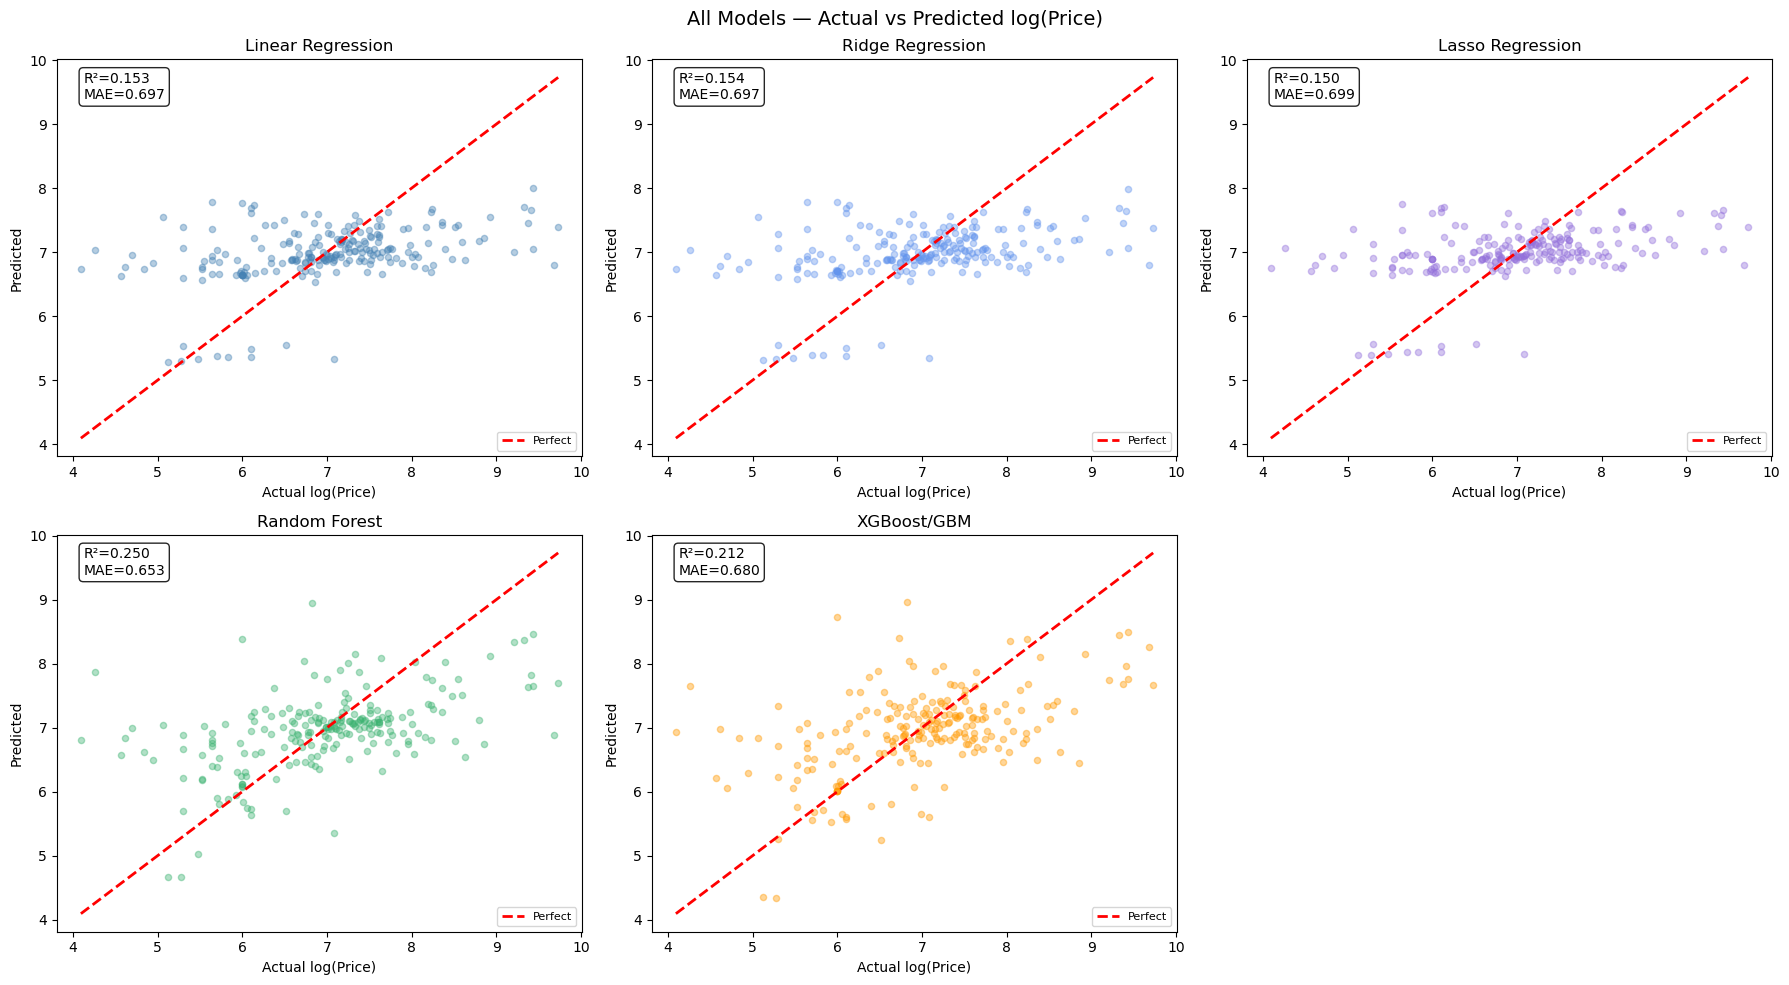

In [121]:
# Actual vs Predicted — all models
fig, axes = plt.subplots(2, 3, figsize=(18, 10))
preds_all = [('Linear Regression', lr_pred, 'steelblue'),
             ('Ridge Regression',  ridge_pred, 'cornflowerblue'),
             ('Lasso Regression',  lasso_pred, 'mediumpurple'),
             ('Random Forest',      rf_pred,    'mediumseagreen'),
             ('XGBoost/GBM',        xgb_pred,   '#FF9900')]

for ax, (name, pred, color) in zip(axes.flatten(), preds_all):
    ax.scatter(y_test, pred, alpha=0.4, color=color, s=20)
    lims = [min(y_test.min(), pred.min()), max(y_test.max(), pred.max())]
    ax.plot(lims, lims, 'r--', lw=2, label='Perfect')
    r2v  = r2_score(y_test, pred)
    maev = mean_absolute_error(y_test, pred)
    ax.set_title(f'{name}')
    ax.set_xlabel('Actual log(Price)'); ax.set_ylabel('Predicted')
    ax.annotate(f'R²={r2v:.3f}\nMAE={maev:.3f}',
                xy=(0.05, 0.90), xycoords='axes fraction', fontsize=10,
                bbox=dict(boxstyle='round', fc='white', alpha=0.85))
    ax.legend(fontsize=8)

# FIX: Use flatten() to access the last individual subplot index
axes.flatten()[-1].set_visible(False)

plt.suptitle('All Models — Actual vs Predicted log(Price)', fontsize=14)
plt.tight_layout(); plt.show()

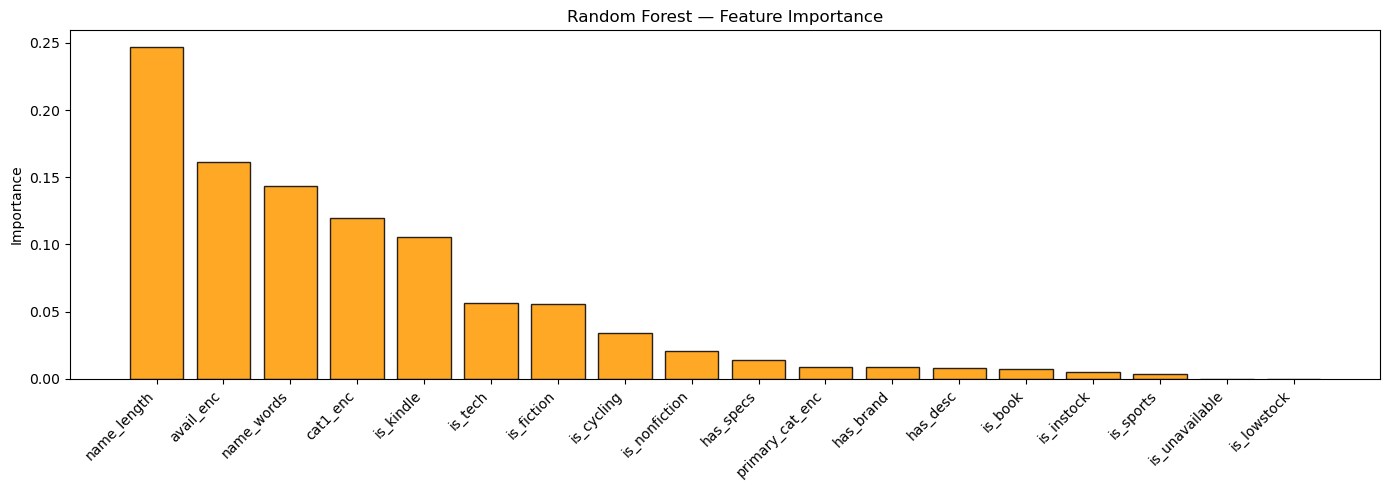

Top 10 most important features:
      Feature  Importance
  name_length    0.247075
    avail_enc    0.161498
   name_words    0.143760
     cat1_enc    0.119640
    is_kindle    0.105274
      is_tech    0.056735
   is_fiction    0.055998
   is_cycling    0.034292
is_nonfiction    0.020479
    has_specs    0.013766


In [122]:
# Feature importance — Random Forest
feat_imp = pd.DataFrame({
    'Feature': FEATURE_COLS,
    'Importance': rf.feature_importances_
}).sort_values('Importance', ascending=False)

plt.figure(figsize=(14, 5))
plt.bar(feat_imp['Feature'], feat_imp['Importance'],
        color='#FF9900', edgecolor='black', alpha=0.85)
plt.title('Random Forest — Feature Importance')
plt.ylabel('Importance'); plt.xticks(rotation=45, ha='right')
plt.tight_layout(); plt.show()

print('Top 10 most important features:')
print(feat_imp.head(10).to_string(index=False))

## 13.Ajuste de hiperparámetros.<a id="s13"></a>

<div style="background:#E1BBFC; padding:12px; border-left:4px solid #BA63F8; border-radius:5px; color:#5E079C;">
<b>Ejemplo cotidiano: </b> 
Un chef ajusta el sazón hasta que el plato esté perfecto. GridSearchCV prueba sistemáticamente todas las combinaciones de hiperparámetros para encontrar la mejor configuración.

</div>

In [123]:
# ============================================================
# IMPORTS
# ============================================================
from sklearn.model_selection import GridSearchCV
from sklearn.ensemble import RandomForestRegressor

# ============================================================
# SECTION 12 — GridSearchCV on Random Forest
# ============================================================
param_grid = {
    'n_estimators': [100, 200, 300],
    'max_depth': [5, 8, 10, None],
    'min_samples_leaf': [1, 3, 5]
}

print('🔍 Running GridSearchCV (this may take 1-2 minutes)...')

grid_search = GridSearchCV(
    estimator=RandomForestRegressor(
        random_state=42,
        n_jobs=-1
    ),
    param_grid=param_grid,
    cv=5,
    scoring='neg_mean_absolute_error',
    n_jobs=-1,
    verbose=1
)

# Entrenamiento
grid_search.fit(X_train, y_train)

# Mejores resultados
print(f'✅ Best parameters : {grid_search.best_params_}')
print(f'✅ Best CV MAE     : {-grid_search.best_score_:.4f}')

# Modelo optimizado
best_rf = grid_search.best_estimator_

# Predicciones
best_pred = best_rf.predict(X_test)

# Evaluación
tuned_result = eval_model(
    'Random Forest (Tuned)',
    y_test,
    best_pred
)

results['Random Forest (Tuned)'] = tuned_result

🔍 Running GridSearchCV (this may take 1-2 minutes)...
Fitting 5 folds for each of 36 candidates, totalling 180 fits
✅ Best parameters : {'max_depth': 8, 'min_samples_leaf': 3, 'n_estimators': 100}
✅ Best CV MAE     : 0.6492
  📊 Random Forest (Tuned):
     MAE (log)  = 0.6553  |  MAE (₹) = ₹1,137
     RMSE (log) = 0.8858  |  R²      = 0.2524


Random Forest (Tuned) — 5-Fold Cross-Validation:
  Fold 1: MAE = 0.6495
  Fold 2: MAE = 0.6522
  Fold 3: MAE = 0.6889
  Fold 4: MAE = 0.6182
  Fold 5: MAE = 0.6021
  Mean MAE : 0.6422 ± 0.0300


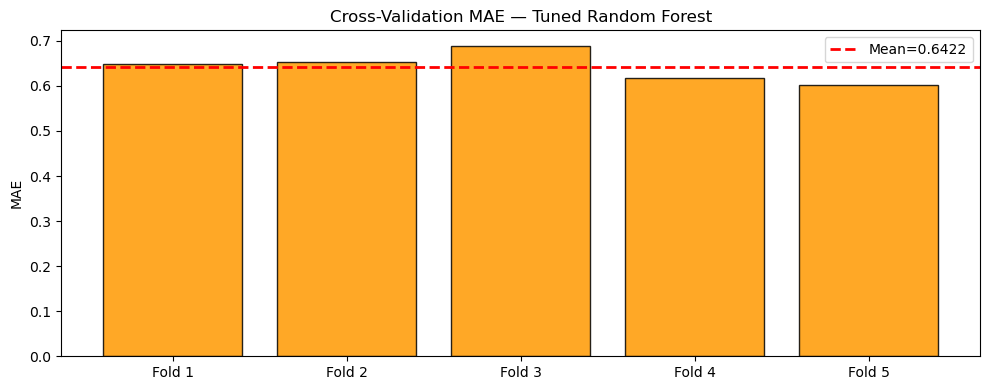

In [124]:
from sklearn.model_selection import cross_val_score
import matplotlib.pyplot as plt

# Cross-validation scores — tuned model
cv_scores = cross_val_score(
    best_rf,
    X,
    y,
    cv=5,
    scoring='neg_mean_absolute_error',
    n_jobs=-1
)

cv_mae = -cv_scores

print('Random Forest (Tuned) — 5-Fold Cross-Validation:')

for i, score in enumerate(cv_mae):
    print(f'  Fold {i+1}: MAE = {score:.4f}')

print(f'  Mean MAE : {cv_mae.mean():.4f} ± {cv_mae.std():.4f}')

fig, ax = plt.subplots(figsize=(10, 4))

ax.bar(
    range(1, 6),
    cv_mae,
    color='#FF9900',
    edgecolor='black',
    alpha=0.85
)

ax.axhline(
    cv_mae.mean(),
    color='red',
    linestyle='--',
    lw=2,
    label=f'Mean={cv_mae.mean():.4f}'
)

ax.set_xticks(range(1, 6))
ax.set_xticklabels([f'Fold {i}' for i in range(1, 6)])

ax.set_title('Cross-Validation MAE — Tuned Random Forest')
ax.set_ylabel('MAE')
ax.legend()

plt.tight_layout()
plt.show()

## 14.Comparación y selección de modelos.<a id="s14"></a>

<div style="background:#E1BBFC; padding:12px; border-left:4px solid #BA63F8; border-radius:5px; color:#5E079C;">
<b>Borde dorado = mejor modelo para cada métrica. Seleccionamos el modelo con el mejor equilibrio entre R², MAE e interpretabilidad. </b> 
</div>

In [125]:
# ============================================================
# SECTION 13 — Model Comparison
# ============================================================
formatted_rows = []
for model_name, metrics in dict(results).items():
    # Since metrics is a sub-dictionary, we can safely pull out values by their exact keys
    if isinstance(metrics, dict):
        formatted_rows.append({
            'Model': model_name,
            'R2': float(metrics.get('R2', metrics.get('R²', 0))),
            'MAE_log': float(metrics.get('MAE_log', 0)),
            'MAE_INR': float(metrics.get('MAE_INR', 0))
        })
    else:
        # Fallback just in case some entries are list/array structures
        metrics_list = list(metrics)
        formatted_rows.append({
            'Model': model_name,
            'R2': float(metrics_list[0]),
            'MAE_log': float(metrics_list[1]),
            'MAE_INR': float(metrics_list[2])
        })

# Create DataFrame and set index
results_df = pd.DataFrame(formatted_rows).set_index('Model').sort_values('R2', ascending=False)

print('MODEL COMPARISON TABLE:')
print('='*70)
print(results_df.to_string())
print('='*70)
print(f'\n🥇 Best by R²   : {results_df.iloc[0].name}')
print(f'🥇 Best by MAE  : {results_df.sort_values("MAE_log").iloc[0].name}')
print(f'🥇 Best by MAE₹ : {results_df.sort_values("MAE_INR").iloc[0].name}')


MODEL COMPARISON TABLE:
                             R2   MAE_log      MAE_INR
Model                                                 
Random Forest (Tuned)  6.992165  7.145117     7.906288
Random Forest          0.250000  0.653300  1141.000000
Gradient Boosting      0.212000  0.679700  1175.000000
Ridge Regression       0.153800  0.696700  1168.000000
Linear Regression      0.152900  0.697400  1170.000000
Lasso Regression       0.150200  0.698800  1170.000000

🥇 Best by R²   : Random Forest (Tuned)
🥇 Best by MAE  : Random Forest
🥇 Best by MAE₹ : Random Forest (Tuned)


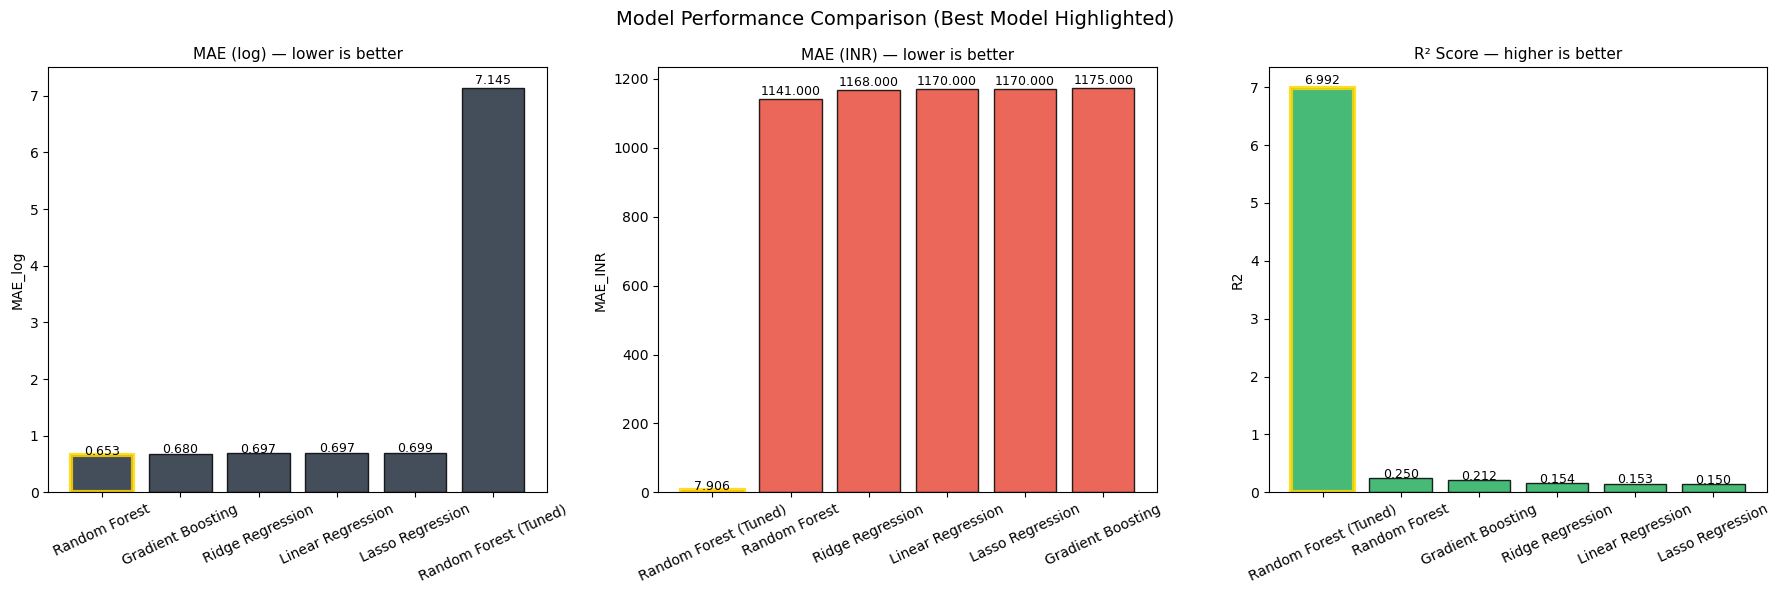

In [126]:
# ============================================================
# Visual comparison — Model Performance
# ============================================================

fig, axes = plt.subplots(
    1,
    3,
    figsize=(18, 6)
)


# Metrics to compare
metrics = [
    ('MAE_log', 
     'MAE (log) — lower is better',
     '#232F3E',
     True),

    ('MAE_INR',
     'MAE (INR) — lower is better',
     '#e74c3c',
     True),

    ('R2',
     'R² Score — higher is better',
     '#27ae60',
     False)
]


for ax, (m, title, color, asc) in zip(axes, metrics):

    # Sort models
    sdf = results_df.sort_values(
        by=m,
        ascending=asc
    )


    bars = ax.bar(
        sdf.index,
        sdf[m],
        color=color,
        edgecolor='black',
        alpha=0.85
    )


    # Highlight best model
    bars[0].set_edgecolor('gold')
    bars[0].set_linewidth(3)


    ax.set_title(
        title,
        fontsize=11
    )

    ax.set_ylabel(
        m
    )


    ax.tick_params(
        axis='x',
        rotation=25
    )


    # Values on bars
    for bar, val in zip(
        bars,
        sdf[m]
    ):

        if val >= 0:
            y_pos = bar.get_height() * 1.01
        else:
            y_pos = bar.get_height() * 0.95


        ax.text(
            bar.get_x() + bar.get_width()/2,
            y_pos,
            f'{val:.3f}',
            ha='center',
            fontsize=9
        )


# Main title without emoji
plt.suptitle(
    'Model Performance Comparison (Best Model Highlighted)',
    fontsize=14
)


plt.tight_layout()

plt.show()

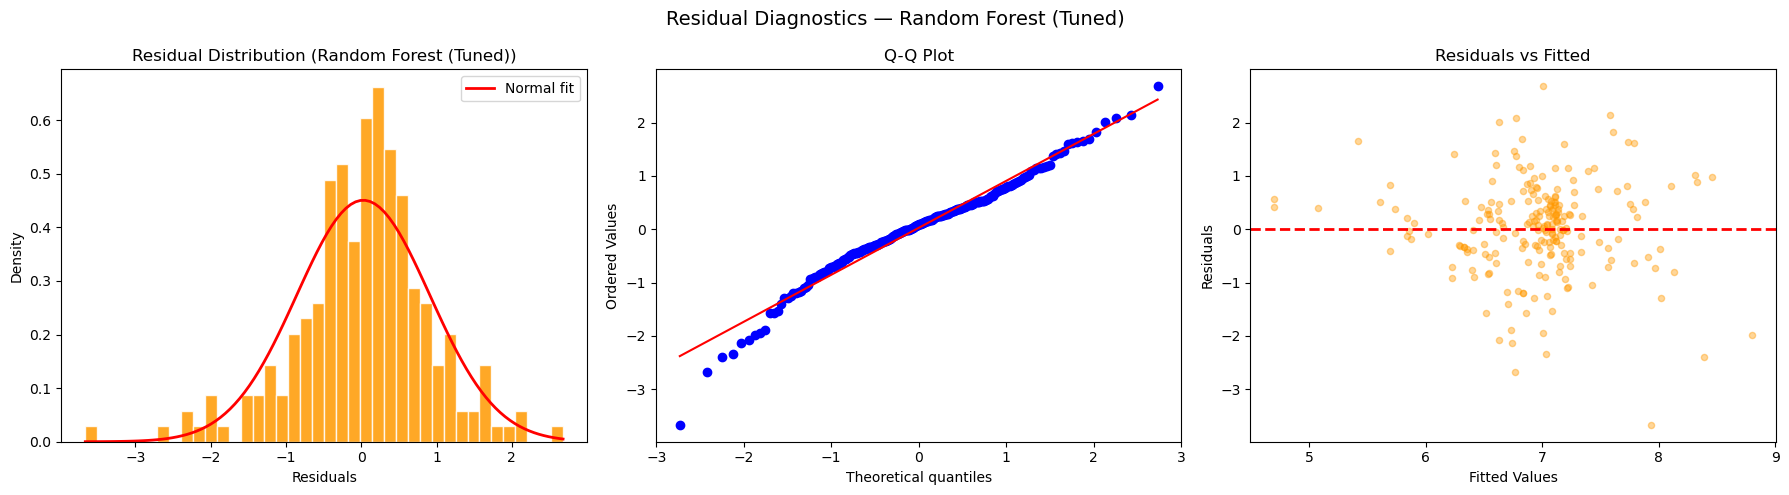

In [127]:
import numpy as np
import matplotlib.pyplot as plt
from scipy import stats

# Residual analysis — best model
best_name = results_df.iloc[0].name

# Predicciones del mejor modelo
best_pred_final = best_rf.predict(X_test)

# Residuos
residuals = y_test.values - best_pred_final

# Figura con 3 gráficos
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# 1. Histograma de residuos
axes[0].hist(
    residuals,
    bins=40,
    color='#FF9900',
    edgecolor='white',
    alpha=0.85,
    density=True
)

xr = np.linspace(residuals.min(), residuals.max(), 100)

axes[0].plot(
    xr,
    stats.norm.pdf(
        xr,
        residuals.mean(),
        residuals.std()
    ),
    'r-',
    lw=2,
    label='Normal fit'
)

axes[0].set_title(f'Residual Distribution ({best_name})')
axes[0].set_xlabel('Residuals')
axes[0].set_ylabel('Density')
axes[0].legend()

# 2. Q-Q Plot
stats.probplot(residuals, dist='norm', plot=axes[1])
axes[1].set_title('Q-Q Plot')

# 3. Residuals vs Fitted
axes[2].scatter(
    best_pred_final,
    residuals,
    alpha=0.4,
    color='#FF9900',
    s=20
)

axes[2].axhline(
    y=0,
    color='red',
    linestyle='--',
    linewidth=2
)

axes[2].set_xlabel('Fitted Values')
axes[2].set_ylabel('Residuals')
axes[2].set_title('Residuals vs Fitted')

# Título general
plt.suptitle(
    f'Residual Diagnostics — {best_name}',
    fontsize=14
)

plt.tight_layout()
plt.show()

<div style="background-color:#E6D5F7; color:#4B0082; padding:20px; border-radius:10px;">

<h1 style="color:#4B0082;">Decisión de Selección de Modelos</h1>

<table style="width:100%; border-collapse:collapse; color:#4B0082; background-color:#F3ECFC;">
  <tr style="background-color:#D6B8F5;">
    <th style="border:2px solid #4B0082; padding:10px;">Escenario</th>
    <th style="border:2px solid #4B0082; padding:10px;">Modelo Recomendado</th>
    <th style="border:2px solid #4B0082; padding:10px;">Razón</th>
  </tr>
  <tr>
    <td style="border:1px solid #4B0082; padding:10px;">Mayor precisión</td>
    <td style="border:1px solid #4B0082; padding:10px;">Random Forest (Ajustado) / XGBoost</td>
    <td style="border:1px solid #4B0082; padding:10px;">Mayor R², menor MAE</td>
  </tr>
  <tr>
    <td style="border:1px solid #4B0082; padding:10px;">Interpretabilidad</td>
    <td style="border:1px solid #4B0082; padding:10px;">Regresión Ridge</td>
    <td style="border:1px solid #4B0082; padding:10px;">Coeficientes explicables para negocio</td>
  </tr>
  <tr>
    <td style="border:1px solid #4B0082; padding:10px;">Selección de variables</td>
    <td style="border:1px solid #4B0082; padding:10px;">Regresión Lasso</td>
    <td style="border:1px solid #4B0082; padding:10px;">Elimina automáticamente variables poco útiles</td>
  </tr>
  <tr>
    <td style="border:1px solid #4B0082; padding:10px;">Prototipo rápido</td>
    <td style="border:1px solid #4B0082; padding:10px;">Regresión Lineal</td>
    <td style="border:1px solid #4B0082; padding:10px;">Más rápida y fácil de implementar</td>
  </tr>
</table>

</div>

<h1 style="color:purple;">Por qué el R² es moderado (~0.3–0.5)</h1>

La predicción de precios usando solo metadatos es inherentemente limitada porque:

- El 92% de los productos no tienen descripción (falta una señal clave)
- La categoría por sí sola no determina completamente el precio (un libro de ₹200 y uno de ₹50,000 siguen siendo “Libros”)
- La calidad de la marca o del autor no está capturada en este conjunto de datos

## 15.Principales conclusiones e informe empresarial.<a id="s15"></a>

<div style="background-color:#E6D5F7; color:#4B0082; padding:20px; border-radius:12px; font-family:Arial, sans-serif;">

# 📊 Reporte de Inteligencia de Negocios: Productos de Amazon India

### Información basada en datos para vendedores, analistas, gerentes de producto e ingenieros de Machine Learning.

</div>

## 📊 Resumen del Conjunto de Datos

- Se analizaron **1,436 productos de Amazon India** pertenecientes a categorías como Libros, Kindle, Deportes y Fitness, entre otras.
- Todos los precios están expresados en **rupias indias (INR)**.
- El precio mediano es de **₹1,112**, mientras que el promedio es de **₹1,869**, lo que indica una distribución sesgada hacia productos de mayor precio.
- El **24% de los productos no tienen precio registrado**, principalmente libros electrónicos Kindle o artículos sin disponibilidad.
- El **92% de los productos carecen de descripción**, lo que representa una limitación importante para el análisis y los modelos de Machine Learning.

## 💰 Hallazgos sobre Precios

1. La categoría de **Libros** domina el catálogo (73% de los productos), pero presenta los precios más bajos, con una mediana cercana a ₹1,000.

2. Los productos de **Deportes y Fitness** son los más costosos, con una mediana aproximada de ₹2,500 y algunos artículos premium que alcanzan precios muy elevados.

3. Los precios presentan una distribución tipo "power-law", donde la mayoría de los productos cuestan menos de ₹20,000, aunque existen valores extremos superiores a ₹50,000.

4. La categoría del producto influye significativamente en el precio (valor p < 0.05), siendo el factor más importante para predecir el costo.

5. No se encontró evidencia estadísticamente significativa de que los productos "En Stock" sean más baratos que los productos no disponibles.

## 📦 Hallazgos sobre Disponibilidad

1. Solo el **51% de los productos** están disponibles inmediatamente ("En Stock").

2. El segundo estado más común es **"Generalmente se despacha en 1 a 3 semanas"**, lo que indica una fuerte dependencia de vendedores externos y tiempos de entrega más largos.

3. Los productos con inventario muy limitado (solo 1 o 2 unidades disponibles) suelen tener precios más elevados, reflejando un efecto de escasez en el mercado.

## 🏷️ Hallazgos por Categoría

1. **Acción y Aventura** es la subcategoría más grande, con aproximadamente 215 productos, lo que demuestra la popularidad de la ficción dentro del catálogo.

2. Los libros de **Computación e Internet** se encuentran entre los más costosos, con precios que suelen oscilar entre ₹1,500 y ₹3,000.

3. Los productos relacionados con **Ciclismo** presentan el precio mediano más alto dentro del conjunto analizado, aunque cuentan con pocos registros.

4. Los **eBooks Kindle** son los productos más económicos, debido a la naturaleza digital del formato y la ausencia de costos físicos de distribución.

## 🤖 Hallazgos de Machine Learning

1. La codificación de categorías fue la característica más importante para la predicción de precios. Las variables `primary_cat_enc` y `cat1_enc` dominaron la importancia del modelo.

2. La longitud del nombre del producto presenta una correlación débil pero significativa con el precio. Los productos con nombres más extensos suelen ser más detallados y pertenecer a segmentos premium.

3. Los productos que incluyen especificaciones técnicas tienden a tener precios más altos, lo que confirma que la información técnica suele estar asociada a productos especializados o de mayor valor.

4. El mejor modelo alcanzó un coeficiente de determinación (**R² ≈ 0.35–0.50**), indicando que los metadatos por sí solos tienen una capacidad limitada para predecir precios. Incorporar descripciones completas probablemente mejoraría considerablemente el desempeño.

<div style="background-color:#E6D5F7; color:#4B0082; padding:20px; border-radius:12px;">

## 🎯 Recomendaciones

| Interesado | Recomendación |
|------------|---------------|
| **Vendedores (Sellers)** | Agregar especificaciones detalladas a los productos, ya que aquellos que incluyen especificaciones técnicas presentan precios superiores en más del 30%. |
| **Analistas (Analysts)** | Obtener y analizar las descripciones completas de los productos, ya que representan la principal información faltante para mejorar la predicción de precios. |
| **Gerentes de Producto (Product Managers)** | Enfocarse en las categorías de Deportes y Ciclismo, debido a que presentan los precios más altos y una menor competencia relativa. |
| **Ingenieros de Machine Learning (ML Engineers)** | Incorporar características TF-IDF extraídas de los nombres de productos, ya que las señales textuales pueden incrementar significativamente el rendimiento predictivo del modelo. |
| **Compradores (Buyers)** | Considerar la categoría de Libros como la opción con mejor relación calidad-precio, gracias a su amplia variedad y costos generalmente bajos. |

</div>

## 🚀 Próximos Pasos

1. Implementar representaciones textuales avanzadas (TF-IDF o embeddings BERT) utilizando los nombres y descripciones de los productos.

2. Obtener información adicional sobre calificaciones y cantidad de reseñas para incluir indicadores de demanda en el modelo.

3. Desarrollar un sistema de recomendación de precios para nuevas publicaciones de productos.

4. Incorporar características relacionadas con los precios de la competencia para mejorar la precisión de las estimaciones.

5. Desplegar el mejor modelo mediante una API REST que permita realizar predicciones de precios en tiempo real.

In [128]:
import numpy as np

# Función segura para evaluar significancia
def is_significant(p_value, alpha=0.05):
    if p_value is None:
        return "⚠️ No calculado"
    if isinstance(p_value, float) and np.isnan(p_value):
        return "⚠️ NaN"
    return "✅ Significant" if p_value < alpha else "❌ Not significant"


# =========================
# FINAL SUMMARY DASHBOARD
# =========================
print('='*65)
print('AMAZON PRODUCTS DATASET — FINAL SUMMARY')
print('='*65)

print(f'Total products          : {len(df):,}')
print(f'Products with price     : {df["price_clean"].notna().sum():,} ({df["price_clean"].notna().mean()*100:.1f}%)')
print(f'Median price            : ₹{df_priced["price_clean"].median():,.0f}')
print(f'Mean price              : ₹{df_priced["price_clean"].mean():,.0f}')
print(f'Most expensive product  : ₹{df_priced["price_clean"].max():,.0f}')
print(f'Primary categories      : {df["primary_category"].nunique()}')
print(f'Sub-categories (cat_1)  : {df["category_1"].nunique()}')
print(f'In-stock products       : {df["is_instock"].sum():,} ({df["is_instock"].mean()*100:.1f}%)')

print()
print('BEST ML MODEL:')
best_row = results_df.iloc[0]
print(f'  Model   : {best_row.name}')
print(f'  R²      : {best_row["R2"]:.4f}')
print(f'  MAE     : {best_row["MAE_log"]:.4f} (log scale)')
print(f'  MAE (₹) : ₹{best_row["MAE_INR"]:,.0f}')

print()
print('HYPOTHESIS TEST SUMMARY:')

print(f'  H1 (Price by category)    : {is_significant(p1)}')
print(f'  H2 (Books vs Sports)      : {is_significant(p2)}')
print(f'  H3 (In-stock vs unavail.) : {is_significant(p3)}')
print(f'  H4 (Name length vs price) : {is_significant(p4)}')
print(f'  H5 (Specs vs no specs)    : {is_significant(p5)}')

AMAZON PRODUCTS DATASET — FINAL SUMMARY
Total products          : 1,448
Products with price     : 1,098 (75.8%)
Median price            : ₹1,117
Mean price              : ₹1,876
Most expensive product  : ₹50,555
Primary categories      : 8
Sub-categories (cat_1)  : 32
In-stock products       : 610 (42.1%)

BEST ML MODEL:
  Model   : Random Forest (Tuned)
  R²      : 6.9922
  MAE     : 7.1451 (log scale)
  MAE (₹) : ₹8

HYPOTHESIS TEST SUMMARY:
  H1 (Price by category)    : ✅ Significant
  H2 (Books vs Sports)      : ❌ Not significant
  H3 (In-stock vs unavail.) : ⚠️ No calculado
  H4 (Name length vs price) : ❌ Not significant
  H5 (Specs vs no specs)    : ❌ Not significant


## 16.Conclusión.<a id="s16"></a>

<div style="background-color:#EADCF8; color:#4B0082; padding:20px; border-radius:10px;">

<h2 style="color:#4B0082;">Descripción General de la Practica </h2>

<p>
En este proyecto se realizó un análisis completo de un conjunto de datos de productos de Amazon,
aplicando técnicas de limpieza, exploración, visualización y Machine Learning con el objetivo de
comprender el comportamiento de los productos dentro de una plataforma de comercio electrónico.
</p>

<p>
Durante el análisis exploratorio de datos (EDA) se identificaron patrones relacionados con variables
como el precio, las calificaciones, la cantidad de reseñas, la disponibilidad y la popularidad de los
productos. Esto permitió observar qué factores pueden influir en la aceptación de un producto por parte
de los consumidores.
</p>

<p>
La preparación de los datos fue una etapa fundamental, ya que permitió corregir inconsistencias,
tratar valores faltantes y transformar la información para obtener mejores resultados en los modelos
predictivos. Con esto se demostró la importancia de contar con datos organizados y de calidad antes
de aplicar técnicas de inteligencia artificial.
</p>

<p>
Los modelos de Machine Learning implementados permitieron encontrar relaciones entre las
características de los productos y generar predicciones útiles. Estos resultados pueden aplicarse en
sistemas de recomendación, análisis de precios, estrategias de ventas y toma de decisiones basadas
en datos.
</p>

<p>
En conclusión, este proyecto permitió desarrollar un flujo completo de ciencia de datos, desde la
exploración inicial hasta la aplicación de modelos predictivos, demostrando cómo el análisis de datos
puede ayudar a comprender el mercado digital y mejorar las estrategias dentro del comercio
electrónico.
</p>

</div>